## Conflict type classifier - NLI approach

We classify conflict types using **natural language inference (NLI)** with `cross-encoder/nli-roberta-base`.

### Input data
Snippets are **conflict-centered**: rather than splitting articles into uniform sliding-window chunks, we locate every sentence in each article that contains a conflict keyword (see `NB2_Unlabeled_Data_Preparation.ipynb`) and build a **100–120 word window** around it. Overlapping windows are merged. This means the model only ever sees text that is anchored to a conflict mention, reducing noise and cutting the inference set from ~73 k to ~4 k snippets.

The 100–120 word target is calibrated for the NLI input format: snippet + definition together fit comfortably within `max_length=256` tokens without truncation.

### Classification strategy
Classification is reframed as NLI: for each snippet we create one `(snippet, definition)` pair per conflict type and ask whether the snippet *entails* that definition. Label = 1 if the conflict type is present, 0 otherwise. This allows the model to leverage the semantic content of the codebook definitions directly, which is particularly useful given the small labeled training set (~319 snippets).

**Setup:**
- Model: `cross-encoder/nli-roberta-base`
- Task: binary entailment — one shared classifier applied once per (snippet, definition) pair; 5 classification decisions per snippet across 5 conflict types
- Loss: weighted cross-entropy + label smoothing (0.1)
- Positive oversampling: 2×
- Split: 80 % train / 20 % validation, stratified by conflict type
- Metric: macro F1 across conflict types
- Threshold: 0.6 (chosen to balance precision/recall per class)
- Early stopping patience = 3, best checkpoint reloaded at end


In [1]:
import pandas as pd

# labeled training data (conflict labels), created in NB1_Labeled_Data_Preparation.ipynb
CONFLICTS_PATH = 'conflicts_labeled.csv'
train_df = pd.read_csv(CONFLICTS_PATH)
print(f'Training snippets loaded : {len(train_df)}')
print(f'Columns                  : {list(train_df.columns)}')

# conflict snippets (score >= 2, created in NB2)
SNIPPETS_PATH = 'conflict_snippets_df_2705.xlsx'
snippets_df = pd.read_excel(SNIPPETS_PATH)
print(f'Quality-filtered snippets loaded : {len(snippets_df):,}')
print(f'Columns                          : {list(snippets_df.columns)}')

Training snippets loaded : 390
Columns                  : ['snippet', 'article_id', 'env_health', 'labour_social', 'governance_corruption', 'economic_industrial', 'geopolitical_strategic']
Quality-filtered snippets loaded : 2,705
Columns                          : ['article_id', 'title', 'outlet', 'date', 'snippet', 'word_count', 'has_indo_content', 'has_china_content', 'has_nickel_adj']


## NLI-based conflict classifier

Instead of mapping snippets to integer class indices, we reframe classification as **natural language inference (NLI)**: for each snippet we create one input pair per conflict type *(snippet, definition)* and ask whether the snippet entails that definition. Label = 1 if the conflict type is present, 0 otherwise.

**Why this is better for our dataset:**
- The model learns from *both* the labeled snippets and the semantic content of the definitions simultaneously
- Definitions remain active at inference time, not just during training
- Compensates for small class sizes (46–95 examples) by using definition text as additional supervision signal
- Particularly helpful for weak classes (Geopolitical, Economic)

The definitions are parsed from the codebook (`conflict_definition_rules` sheet), combining the general definition, coding signals, key actors, and include/exclude rules into a single rich text per conflict type.


**Note on governance & corruption:** This class consistently produces the lowest F1 scores regardless of model or hyperparameter choices. Low performance reflects definitional ambiguity in the training labels — governance violations and labour/social conflict often co-occur — rather than insufficient model capacity.


In [2]:
import pandas as pd

CB_PATH = r'../ln_labeling/Codebook_Actor_Roles_Conflicts.xlsx'
raw = pd.read_excel(CB_PATH, sheet_name='conflict_definition_rules', header=None)

# map codebook conflict names to standardized column names
LABEL_MAP = {
    'Environmental& health Conflicts'       : 'env_health',
    'Labor & Social Conflicts'               : 'labour_social',
    'Governance & Corruption Conflicts'      : 'governance_corruption',
    'Economic & Industrial Policy Conflicts' : 'economic_industrial',
    'Geopolitical & Strategic Conflicts'     : 'geopolitical_strategic',
}

def clean(v):
    return str(v).strip() if str(v) != 'nan' else ''

# section 1: general definitions (rows 1-5, cols 0-1)
sec1 = {clean(raw.iloc[i, 0]): clean(raw.iloc[i, 1]) for i in range(1, 6)}

# section 2: signals, actors, include, exclude (rows 9-13, cols 0-4)
sec2 = {}
for i in range(9, 14):
    name    = clean(raw.iloc[i, 0])
    signals = clean(raw.iloc[i, 1])
    actors  = clean(raw.iloc[i, 2])
    include = clean(raw.iloc[i, 3])
    exclude = clean(raw.iloc[i, 4])
    sec2[name] = {'signals': signals, 'actors': actors,
                  'include': include, 'exclude': exclude}

# build one rich definition string per conflict type
conflict_definitions = {}
for cb_name, std_name in LABEL_MAP.items():
    parts = []
    if cb_name in sec1 and sec1[cb_name]:
        parts.append(f"Definition: {sec1[cb_name]}")
    if cb_name in sec2:
        s = sec2[cb_name]
        if s['signals'] : parts.append(f"Signals: {s['signals']}")
        if s['actors']  : parts.append(f"Key actors: {s['actors']}")
        if s['include'] : parts.append(f"Include when: {s['include']}")
        if s['exclude'] : parts.append(f"Exclude when: {s['exclude']}")
    conflict_definitions[std_name] = ' | '.join(parts)

print('Conflict definitions built:\n')
for k, v in conflict_definitions.items():
    print(f'{k}:\n  {v[:120]}...\n')

lines = ['CONFLICT TYPE DEFINITIONS\n', '=' * 60 + '\n\n']
for cb_name, display_name in LABEL_MAP.items():
    lines.append(f'{display_name}\n')
    lines.append('-' * len(display_name) + '\n')
    if cb_name in sec1:
        lines.append(f'Definition  : {sec1[cb_name]}\n')
    if cb_name in sec2:
        s = sec2[cb_name]
        if s['signals'] : lines.append(f'Signals     : {s["signals"]}\n')
        if s['actors']  : lines.append(f'Key actors  : {s["actors"]}\n')
        if s['include'] : lines.append(f'Include when: {s["include"]}\n')
        if s['exclude'] : lines.append(f'Exclude when: {s["exclude"]}\n')
    lines.append('\n')
    
OUT_TXT = r'conflict_definitions.txt'
with open(OUT_TXT, 'w', encoding='utf-8') as f:
    f.writelines(lines)

print(''.join(lines))
print(f'Saved: {OUT_TXT}')

Conflict definitions built:

env_health:
  Definition: Conflicts arising from the environmental and public health impacts of nickel-related activities, including e...

labour_social:
  Definition: Conflicts in which the primary grievance concerns workers, employment relations, workplace safety, labour co...

governance_corruption:
  Definition: Conflicts in which the primary grievance concerns the exercise, failure, abuse, or contestation of public au...

economic_industrial:
  Definition: Conflicts in which the central dispute concerns the economic consequences, design, or distributive effects o...

geopolitical_strategic:
  Definition: Conflicts in which nickel is framed as a strategic resource within international rivalry, supply-chain secur...

CONFLICT TYPE DEFINITIONS

env_health
----------
Definition  : Conflicts arising from the environmental and public health impacts of nickel-related activities, including extraction, processing, and waste disposal.
Signals     : pollution (ai

In [3]:
# restructure train_df into NLI pairs (snippet, definition, label) 
CONFLICT_COLS = ['env_health', 'labour_social', 'governance_corruption',
                 'economic_industrial', 'geopolitical_strategic']

nli_rows = []
for _, row in train_df.iterrows():
    for col in CONFLICT_COLS:
        nli_rows.append({
            'snippet'        : row['snippet'],
            'conflict_type'  : col,
            'definition'     : conflict_definitions[col],
            'label'          : int(row[col]),
        })

nli_df = pd.DataFrame(nli_rows)

print(f'NLI pairs total          : {len(nli_df):,}')
print(f'  positive (entails=1)   : {nli_df["label"].sum():,}')
print(f'  negative (entails=0)   : {(nli_df["label"]==0).sum():,}')
print(f'\nPairs per conflict type:')
print(nli_df.groupby('conflict_type')['label'].agg(['sum','count'])
        .rename(columns={'sum':'positives','count':'total'}))
nli_df.head(3)


NLI pairs total          : 1,950
  positive (entails=1)   : 399
  negative (entails=0)   : 1,551

Pairs per conflict type:
                        positives  total
conflict_type                           
economic_industrial            75    390
env_health                     88    390
geopolitical_strategic         66    390
governance_corruption          73    390
labour_social                  97    390


,snippet,conflict_type,definition,label
0,But many Indonesian politicians charge that mi...,env_health,Definition: Conflicts arising from the environ...,0
1,But many Indonesian politicians charge that mi...,labour_social,Definition: Conflicts in which the primary gri...,0
2,But many Indonesian politicians charge that mi...,governance_corruption,Definition: Conflicts in which the primary gri...,0


In [4]:
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, EarlyStoppingCallback
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
import torch
import pandas as pd
from torch.utils.data import Dataset
import numpy as np

NLI_MODEL = 'cross-encoder/nli-roberta-base'  # full RoBERTa (was distilroberta)
MAX_LEN   = 256
THRESHOLD = 0.6

tokenizer_nli = AutoTokenizer.from_pretrained(NLI_MODEL)

class NLIDataset(Dataset):
    def __init__(self, snippets, definitions, labels=None):
        self.enc = tokenizer_nli(
            snippets, definitions,
            truncation=True, padding=True, max_length=MAX_LEN
        )
        self.labels = labels
    def __len__(self): return len(self.enc['input_ids'])
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.enc.items()}
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

nli_train_raw, nli_val = train_test_split(
    nli_df, test_size=0.2, random_state=42, stratify=nli_df['conflict_type']
)
nli_val = nli_val.reset_index(drop=True)

# Oversample positive pairs 2x so model sees more conflict examples per epoch
pos_train = nli_train_raw[nli_train_raw['label'] == 1]
nli_train  = pd.concat([nli_train_raw, pos_train]).sample(frac=1, random_state=42).reset_index(drop=True)
print(f'After oversampling — train: {len(nli_train)}  '
      f'(pos={nli_train["label"].sum()}, neg={(nli_train["label"]==0).sum()})  '
      f'val: {len(nli_val)}')

train_ds = NLIDataset(nli_train['snippet'].tolist(),
                      nli_train['definition'].tolist(),
                      nli_train['label'].tolist())
val_ds   = NLIDataset(nli_val['snippet'].tolist(),
                      nli_val['definition'].tolist(),
                      nli_val['label'].tolist())

model_nli = AutoModelForSequenceClassification.from_pretrained(
    NLI_MODEL, num_labels=2, ignore_mismatched_sizes=True
)
print(f'Model labels: {model_nli.config.id2label}')

n_neg = (nli_train['label'] == 0).sum()
n_pos = (nli_train['label'] == 1).sum()
class_weights = torch.tensor([1.0, n_neg / n_pos]).float()
print(f'Class weights: no-conflict={class_weights[0]:.2f}, conflict={class_weights[1]:.2f}')

class WeightedCETrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        loss = torch.nn.CrossEntropyLoss(
            weight=class_weights.to(outputs.logits.device)
        )(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics_nli(eval_pred):
    logits, labels = eval_pred
    probs  = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()
    preds  = (probs >= THRESHOLD).astype(int)
    labels = labels.astype(int).flatten()
    return {
        'f1'       : f1_score(labels, preds, zero_division=0),
        'f1_macro' : f1_score(labels, preds, average='macro', zero_division=0),
    }

MODEL_DIR_NLI = r'nli_conflict_model'

args_nli = TrainingArguments(
    output_dir                  = MODEL_DIR_NLI,
    num_train_epochs            = 10,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1_macro',
    greater_is_better           = True,
    learning_rate               = 2e-5,
    warmup_ratio                = 0.1,
    weight_decay                = 0.1,
    label_smoothing_factor      = 0.1,
    logging_steps               = 10,
    seed                        = 42,
    report_to                   = 'none',
)

trainer_nli = WeightedCETrainer(
    model           = model_nli,
    args            = args_nli,
    train_dataset   = train_ds,
    eval_dataset    = val_ds,
    compute_metrics = compute_metrics_nli,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=3)],
)

trainer_nli.train()

# Final evaluation
pred_out   = trainer_nli.predict(val_ds)
probs_val  = torch.softmax(torch.tensor(pred_out.predictions), dim=-1)[:, 1].numpy()
preds_val  = (probs_val >= THRESHOLD).astype(int)
labels_val = nli_val['label'].values.astype(int)
print(classification_report(labels_val, preds_val,
                             target_names=['no conflict', 'conflict'], zero_division=0))

nli_val_res = nli_val.copy().reset_index(drop=True)
nli_val_res['pred'] = preds_val
nli_val_res['prob'] = probs_val.round(4)
print(f'\nPer conflict type F1 (threshold={THRESHOLD}):')
per_type_f1s = []
for ctype, grp in nli_val_res.groupby('conflict_type'):
    f1 = f1_score(grp['label'], grp['pred'], zero_division=0)
    per_type_f1s.append(f1)
    print(f'  {ctype:<30} F1={f1:.2f}  (n={len(grp)}, pos={grp["label"].sum()})')
print(f'  Macro F1 (per-type avg): {np.mean(per_type_f1s):.3f}')


/home/charlott/.local/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


After oversampling — train: 1894  (pos=668, neg=1226)  val: 390


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at cross-encoder/nli-roberta-base and are newly initialized because the shapes did not match:
- classifier.out_proj.bias: found shape torch.Size([3]) in the checkpoint and torch.Size([2]) in the model instantiated
- classifier.out_proj.weight: found shape torch.Size([3, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model labels: {0: 'LABEL_0', 1: 'LABEL_1'}
Class weights: no-conflict=1.00, conflict=1.84


Epoch,Training Loss,Validation Loss,F1,F1 Macro
1,0.694300,0.639110,0.204082,0.544856
2,0.382800,0.502958,0.533333,0.704065
3,0.272900,0.424361,0.606897,0.758566
4,0.317100,0.610938,0.604651,0.763155
5,0.164700,0.856968,0.625000,0.764113
6,0.031400,0.935940,0.617450,0.763558
7,0.032400,0.894149,0.657534,0.789335
8,0.024000,0.944979,0.643836,0.780908
9,0.008300,0.957673,0.652482,0.787900
10,0.054000,0.985842,0.661871,0.794274


              precision    recall  f1-score   support

 no conflict       0.94      0.91      0.93       325
    conflict       0.62      0.71      0.66        65

    accuracy                           0.88       390
   macro avg       0.78      0.81      0.79       390
weighted avg       0.89      0.88      0.88       390


Per conflict type F1 (threshold=0.6):
  economic_industrial            F1=0.57  (n=78, pos=12)
  env_health                     F1=0.81  (n=78, pos=15)
  geopolitical_strategic         F1=0.59  (n=78, pos=10)
  governance_corruption          F1=0.22  (n=78, pos=12)
  labour_social                  F1=0.88  (n=78, pos=16)
  Macro F1 (per-type avg): 0.616


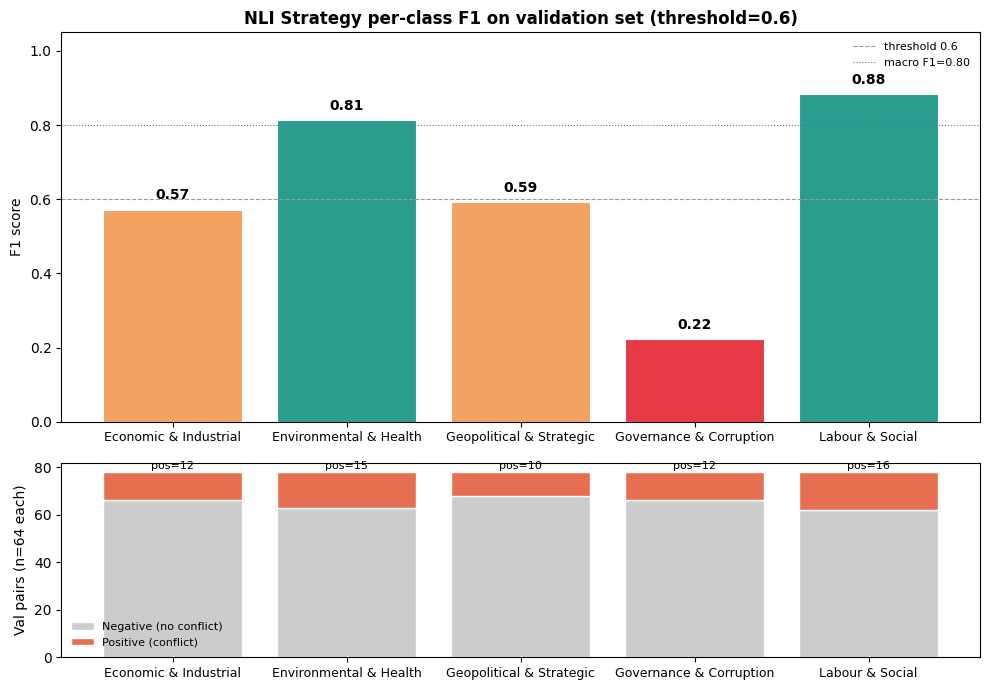

Saved: nli_f1_by_class.png


In [5]:
# Compute per-class F1 from validation results
THRESHOLD = 0.6
f1_data = {}
for ctype, grp in nli_val_res.groupby('conflict_type'):
    f1 = f1_score(grp['label'], grp['pred'], zero_division=0)
    pos = grp['label'].sum()
    neg = len(grp) - pos
    display_name = {
        'env_health': 'Environmental & Health',
        'labour_social': 'Labour & Social',
        'governance_corruption': 'Governance & Corruption',
        'economic_industrial': 'Economic & Industrial',
        'geopolitical_strategic': 'Geopolitical & Strategic'
    }[ctype]
    f1_data[display_name] = {'f1': f1, 'pos': pos, 'neg': neg}

import matplotlib.pyplot as plt
import numpy as np

labels  = list(f1_data.keys())
f1s     = [f1_data[l]['f1']  for l in labels]
pos     = [f1_data[l]['pos'] for l in labels]
neg     = [f1_data[l]['neg'] for l in labels]
colors  = ['#e63946' if f < 0.5 else '#f4a261' if f < 0.7 else '#2a9d8f' for f in f1s]

x = np.arange(len(labels))
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), gridspec_kw={'height_ratios': [2, 1]})

# top: F1 bars
bars = ax1.bar(x, f1s, color=colors, edgecolor='white', linewidth=0.8)
ax1.axhline(THRESHOLD, color='#999', linestyle='--', linewidth=0.8, label=f'threshold {THRESHOLD}')
ax1.axhline(0.80, color='#457b9d', linestyle=':', linewidth=0.8, label='macro F1=0.80')
for bar, f in zip(bars, f1s):
    ax1.text(bar.get_x() + bar.get_width()/2, f + 0.02, f'{f:.2f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=9)
ax1.set_ylim(0, 1.05)
ax1.set_ylabel('F1 score')
ax1.set_title(f'NLI Strategy per-class F1 on validation set (threshold={THRESHOLD})', fontweight='bold')
ax1.legend(fontsize=8, frameon=False)

# bottom: pos/neg support stacked bars
ax2.bar(x, neg, label='Negative (no conflict)', color='#ccc', edgecolor='white')
ax2.bar(x, pos, bottom=neg, label='Positive (conflict)', color='#e76f51', edgecolor='white')
for i, (p, n) in enumerate(zip(pos, neg)):
    ax2.text(i, n + p + 0.5, f'pos={p}', ha='center', va='bottom', fontsize=8)
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=9)
ax2.set_ylabel('Val pairs (n=64 each)')
ax2.legend(fontsize=8, frameon=False)

plt.tight_layout()
OUT = r'nli_f1_by_class.png'
plt.savefig(OUT, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT}')


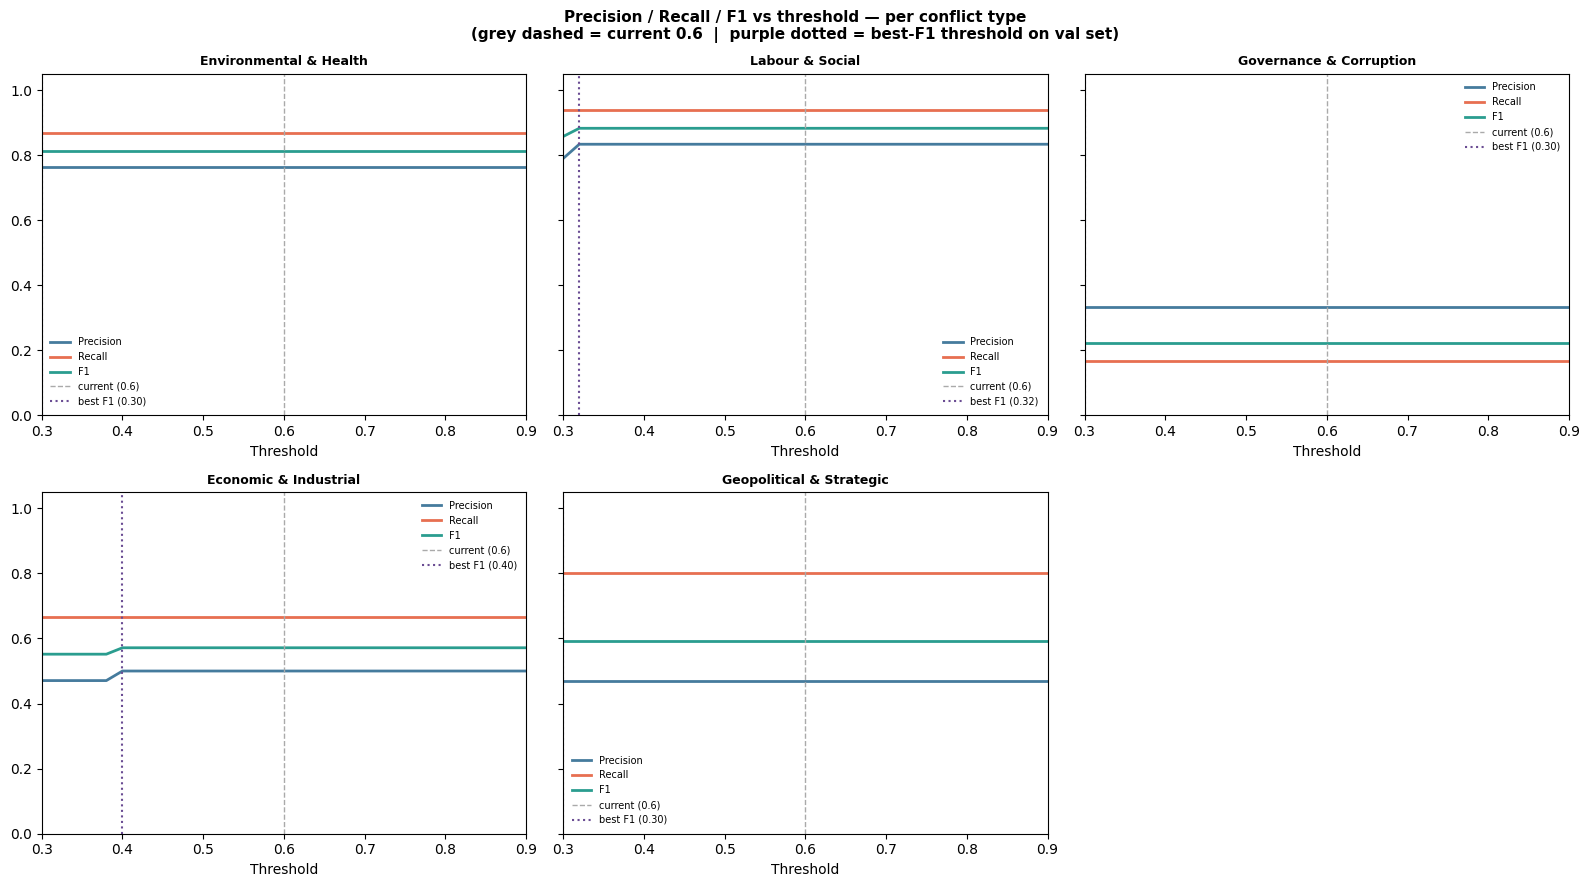

Saved: conflict_threshold_curves.png

Best-F1 threshold per class (val set):
  Environmental & Health            best t=0.30  F1=0.81  (vs t=0.60 → F1=0.81,  Δ=+0.00)
  Labour & Social                   best t=0.32  F1=0.88  (vs t=0.60 → F1=0.88,  Δ=+0.00)
  Governance & Corruption           best t=0.30  F1=0.22  (vs t=0.60 → F1=0.22,  Δ=+0.00)
  Economic & Industrial             best t=0.40  F1=0.57  (vs t=0.60 → F1=0.57,  Δ=+0.00)
  Geopolitical & Strategic          best t=0.30  F1=0.59  (vs t=0.60 → F1=0.59,  Δ=+0.00)


In [6]:
# Threshold justification: precision / recall / F1 vs threshold per class
# Shows whether 0.6 is near the F1-optimal point and how precision/recall trade off.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

CONFLICT_COLS = ['env_health', 'labour_social', 'governance_corruption',
                 'economic_industrial', 'geopolitical_strategic']
LABELS = {
    'env_health'            : 'Environmental & Health',
    'labour_social'         : 'Labour & Social',
    'governance_corruption' : 'Governance & Corruption',
    'economic_industrial'   : 'Economic & Industrial',
    'geopolitical_strategic': 'Geopolitical & Strategic',
}

thresholds = np.arange(0.30, 0.91, 0.02)

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)
axes = axes.flatten()
best_thresholds = {}

for ax, col in zip(axes, CONFLICT_COLS):
    grp    = nli_val_res[nli_val_res['conflict_type'] == col].reset_index(drop=True)
    y_true = grp['label'].values

    precisions, recalls, f1s = [], [], []
    for t in thresholds:
        y_pred = (grp['prob'] >= t).astype(int).values
        precisions.append(precision_score(y_true, y_pred, zero_division=0))
        recalls.append(recall_score(y_true, y_pred, zero_division=0))
        f1s.append(f1_score(y_true, y_pred, zero_division=0))

    best_t = thresholds[np.argmax(f1s)]
    best_thresholds[col] = round(float(best_t), 2)

    ax.plot(thresholds, precisions, color='#457b9d', linewidth=2, label='Precision')
    ax.plot(thresholds, recalls,   color='#e76f51', linewidth=2, label='Recall')
    ax.plot(thresholds, f1s,       color='#2a9d8f', linewidth=2, label='F1')
    ax.axvline(0.6,    color='#aaa',    linestyle='--', linewidth=1,   label='current (0.6)')
    ax.axvline(best_t, color='#6a4c93', linestyle=':',  linewidth=1.5, label=f'best F1 ({best_t:.2f})')
    ax.set_title(LABELS[col], fontsize=9, fontweight='bold')
    ax.set_xlabel('Threshold')
    ax.set_xlim(0.30, 0.90)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7, frameon=False)

axes[-1].set_visible(False)

fig.suptitle(
    'Precision / Recall / F1 vs threshold — per conflict type\n'
    '(grey dashed = current 0.6  |  purple dotted = best-F1 threshold on val set)',
    fontsize=11, fontweight='bold',
)
plt.tight_layout()
OUT = r'conflict_threshold_curves.png'
plt.savefig(OUT, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT}')

print('\nBest-F1 threshold per class (val set):')
for col, t in best_thresholds.items():
    grp        = nli_val_res[nli_val_res['conflict_type'] == col]
    y_true     = grp['label'].values
    f1_best    = f1_score(y_true, (grp['prob'] >= t).astype(int),   zero_division=0)
    f1_current = f1_score(y_true, (grp['prob'] >= 0.6).astype(int), zero_division=0)
    delta      = f1_best - f1_current
    print(f'  {LABELS[col]:<32}  best t={t:.2f}  F1={f1_best:.2f}  '
          f'(vs t=0.60 → F1={f1_current:.2f},  Δ={delta:+.2f})')


## cross validation


── Fold 1/5 ──────────────────────────────────
  train=1880 (pos=640)  val=390


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at cross-encoder/nli-roberta-base and are newly initialized because the shapes did not match:
- classifier.out_proj.bias: found shape torch.Size([3]) in the checkpoint and torch.Size([2]) in the model instantiated
- classifier.out_proj.weight: found shape torch.Size([3, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,F1 Macro
1,0.693900,0.750044,0.279476,0.490010


    env_health                      F1=0.59  (pos=18)
    labour_social                   F1=0.81  (pos=17)
    governance_corruption           F1=0.64  (pos=12)
    economic_industrial             F1=0.32  (pos=17)
    geopolitical_strategic          F1=0.69  (pos=15)

── Fold 2/5 ──────────────────────────────────
  train=1880 (pos=640)  val=390


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at cross-encoder/nli-roberta-base and are newly initialized because the shapes did not match:
- classifier.out_proj.bias: found shape torch.Size([3]) in the checkpoint and torch.Size([2]) in the model instantiated
- classifier.out_proj.weight: found shape torch.Size([3, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Epoch,Training Loss,Validation Loss,F1,F1 Macro
1,0.691500,0.578786,0.280000,0.587059
2,0.458500,0.480233,0.680412,0.787305
3,0.291300,0.482135,0.676923,0.784615
4,0.199100,0.577729,0.695122,0.806977
5,0.127100,0.796233,0.684564,0.805039
6,0.141500,0.872367,0.693878,0.811394
7,0.052000,0.893488,0.708861,0.817453
8,0.046400,1.105526,0.644295,0.780151
9,0.018800,1.032158,0.679739,0.800794
10,0.019800,1.034521,0.679739,0.800794


    env_health                      F1=0.60  (pos=14)
    labour_social                   F1=0.94  (pos=24)
    governance_corruption           F1=0.56  (pos=14)
    economic_industrial             F1=0.62  (pos=15)
    geopolitical_strategic          F1=0.64  (pos=14)

── Fold 5/5 ──────────────────────────────────
  train=1879 (pos=638)  val=390


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at cross-encoder/nli-roberta-base and are newly initialized because the shapes did not match:
- classifier.out_proj.bias: found shape torch.Size([3]) in the checkpoint and torch.Size([2]) in the model instantiated
- classifier.out_proj.weight: found shape torch.Size([3, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,F1 Macro
1,0.699400,0.702473,0.198347,0.525577
2,0.661400,0.634391,0.191489,0.540351
3,0.537300,0.655043,0.433735,0.640320
4,0.428800,0.493621,0.569948,0.714276
5,0.332800,0.545122,0.532609,0.694157
6,0.289500,0.558789,0.614458,0.755112
7,0.229900,0.664037,0.594595,0.749829
8,0.165100,0.811007,0.588235,0.743878
9,0.077600,0.912036,0.537931,0.716210


    env_health                      F1=0.68  (pos=21)
    labour_social                   F1=0.80  (pos=17)
    governance_corruption           F1=0.52  (pos=15)
    economic_industrial             F1=0.41  (pos=12)
    geopolitical_strategic          F1=0.61  (pos=15)

Class                              CV mean    ±std     min     max  single split
──────────────────────────────────────────────────────────────────────────────
  Environmental & Health              0.69    0.09    0.59    0.80          0.81
  Labour & Social                     0.87    0.06    0.80    0.95          0.88
  Governance & Corruption             0.48    0.13    0.29    0.64          0.22
  Economic & Industrial               0.58    0.19    0.32    0.86          0.57
  Geopolitical & Strategic            0.69    0.07    0.61    0.80          0.59
  Macro avg                           0.66


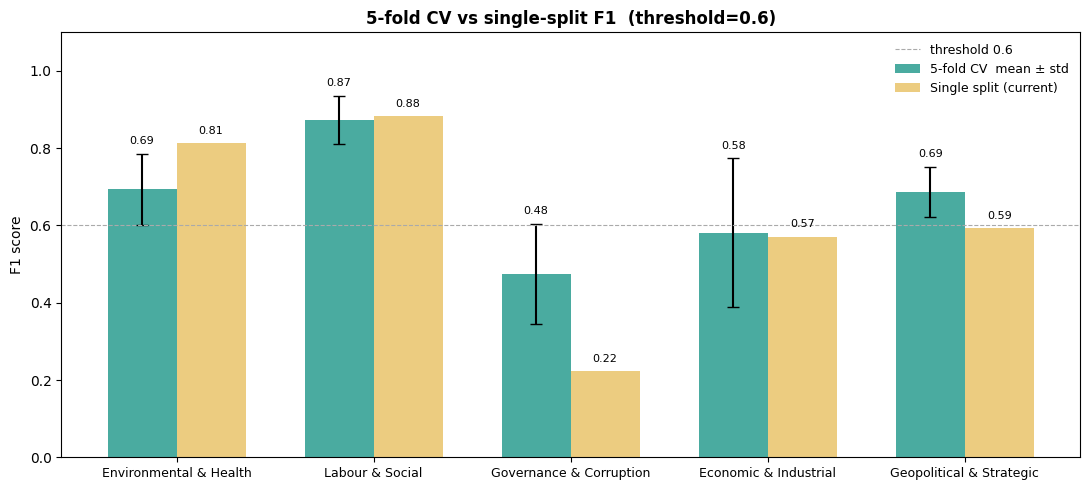

Saved: conflict_cv_f1.png


In [7]:
# 5-fold cross-validation
# Trains the model 5× from scratch — computationally expensive (~5× training time).
# Splits at the SNIPPET level so no text appears in both train and val within a fold.

from sklearn.model_selection import KFold
from transformers import AutoModelForSequenceClassification, TrainingArguments, EarlyStoppingCallback, Trainer
from sklearn.metrics import f1_score
import torch, numpy as np, pandas as pd
import matplotlib.pyplot as plt

CONFLICT_COLS = ['env_health', 'labour_social', 'governance_corruption',
                 'economic_industrial', 'geopolitical_strategic']
LABELS = {
    'env_health'            : 'Environmental & Health',
    'labour_social'         : 'Labour & Social',
    'governance_corruption' : 'Governance & Corruption',
    'economic_industrial'   : 'Economic & Industrial',
    'geopolitical_strategic': 'Geopolitical & Strategic',
}
THRESHOLD = 0.6
K_FOLDS   = 5

class FoldTrainer(Trainer):
    """WeightedCETrainer variant that takes per-fold class weights as an argument."""
    def __init__(self, fold_weights, **kwargs):
        super().__init__(**kwargs)
        self._fold_weights = fold_weights
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        loss    = torch.nn.CrossEntropyLoss(
            weight=self._fold_weights.to(outputs.logits.device)
        )(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

def cv_metrics(eval_pred):
    logits, labels = eval_pred
    probs  = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()
    preds  = (probs >= THRESHOLD).astype(int)
    labels = labels.astype(int).flatten()
    return {
        'f1'      : f1_score(labels, preds, zero_division=0),
        'f1_macro': f1_score(labels, preds, average='macro', zero_division=0),
    }

def make_nli_pairs(df):
    rows = []
    for _, row in df.iterrows():
        for col in CONFLICT_COLS:
            rows.append({
                'snippet'      : row['snippet'],
                'conflict_type': col,
                'definition'   : conflict_definitions[col],
                'label'        : int(row[col]),
            })
    return pd.DataFrame(rows)

kf       = KFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
fold_f1s = {col: [] for col in CONFLICT_COLS}

for fold, (tr_idx, va_idx) in enumerate(kf.split(train_df)):
    print(f'\n── Fold {fold+1}/{K_FOLDS} ──────────────────────────────────')

    fold_train = make_nli_pairs(train_df.iloc[tr_idx].reset_index(drop=True))
    fold_val   = make_nli_pairs(train_df.iloc[va_idx].reset_index(drop=True))

    # 2× positive oversampling, same as main training
    pos = fold_train[fold_train['label'] == 1]
    fold_train = pd.concat([fold_train, pos]).sample(frac=1, random_state=42).reset_index(drop=True)

    ds_tr = NLIDataset(fold_train['snippet'].tolist(),
                       fold_train['definition'].tolist(),
                       fold_train['label'].tolist())
    ds_va = NLIDataset(fold_val['snippet'].tolist(),
                       fold_val['definition'].tolist(),
                       fold_val['label'].tolist())

    n_neg_f = (fold_train['label'] == 0).sum()
    n_pos_f = (fold_train['label'] == 1).sum()
    wts = torch.tensor([1.0, n_neg_f / n_pos_f]).float()
    print(f'  train={len(fold_train)} (pos={n_pos_f})  val={len(fold_val)}')

    fold_model = AutoModelForSequenceClassification.from_pretrained(
        NLI_MODEL, num_labels=2, ignore_mismatched_sizes=True
    )
    fold_args = TrainingArguments(
        output_dir                  = f'cv_fold_{fold}',
        num_train_epochs            = 10,
        per_device_train_batch_size = 16,
        per_device_eval_batch_size  = 32,
        eval_strategy               = 'epoch',
        save_strategy               = 'epoch',
        load_best_model_at_end      = True,
        metric_for_best_model       = 'f1_macro',
        greater_is_better           = True,
        learning_rate               = 2e-5,
        warmup_ratio                = 0.1,
        weight_decay                = 0.1,
        label_smoothing_factor      = 0.1,
        logging_steps               = 50,
        seed                        = 42,
        report_to                   = 'none',
    )
    trainer_fold = FoldTrainer(
        fold_weights    = wts,
        model           = fold_model,
        args            = fold_args,
        train_dataset   = ds_tr,
        eval_dataset    = ds_va,
        compute_metrics = cv_metrics,
        callbacks       = [EarlyStoppingCallback(early_stopping_patience=3)],
    )
    trainer_fold.train()

    pred_out     = trainer_fold.predict(ds_va)
    probs_fold   = torch.softmax(torch.tensor(pred_out.predictions), dim=-1)[:, 1].numpy()
    val_res_fold = fold_val.copy().reset_index(drop=True)
    val_res_fold['pred'] = (probs_fold >= THRESHOLD).astype(int)

    for col in CONFLICT_COLS:
        grp = val_res_fold[val_res_fold['conflict_type'] == col]
        f1  = f1_score(grp['label'], grp['pred'], zero_division=0)
        fold_f1s[col].append(f1)
        print(f'    {col:<30}  F1={f1:.2f}  (pos={grp["label"].sum()})')

# ── Summary table ──────────────────────────────────────────────────────────
single_f1 = {
    col: f1_score(
        nli_val_res[nli_val_res['conflict_type'] == col]['label'],
        nli_val_res[nli_val_res['conflict_type'] == col]['pred'],
        zero_division=0,
    )
    for col in CONFLICT_COLS
}

print(f'\n{"Class":<32}  {"CV mean":>8}  {"±std":>6}  {"min":>6}  {"max":>6}  {"single split":>12}')
print('─' * 78)
for col in CONFLICT_COLS:
    f1s = fold_f1s[col]
    print(f'  {LABELS[col]:<30}  {np.mean(f1s):>8.2f}  {np.std(f1s):>6.2f}'
          f'  {np.min(f1s):>6.2f}  {np.max(f1s):>6.2f}  {single_f1[col]:>12.2f}')
macro_cv = np.mean([np.mean(fold_f1s[c]) for c in CONFLICT_COLS])
print(f'  {"Macro avg":<30}  {macro_cv:>8.2f}')

# ── Bar chart: CV mean ± std vs single split ───────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
x     = np.arange(len(CONFLICT_COLS))
w     = 0.35
means = [np.mean(fold_f1s[c]) for c in CONFLICT_COLS]
stds  = [np.std(fold_f1s[c])  for c in CONFLICT_COLS]
ss    = [single_f1[c]         for c in CONFLICT_COLS]

bars_cv = ax.bar(x - w/2, means, w, yerr=stds, capsize=4,
                 color='#2a9d8f', alpha=0.85, label='5-fold CV  mean ± std')
bars_ss = ax.bar(x + w/2, ss,    w,
                 color='#e9c46a', alpha=0.85, label='Single split (current)')

for bar, m, s in zip(bars_cv, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, m + s + 0.02,
            f'{m:.2f}', ha='center', va='bottom', fontsize=8)
for bar, v in zip(bars_ss, ss):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.02,
            f'{v:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([LABELS[c] for c in CONFLICT_COLS], fontsize=9)
ax.set_ylim(0, 1.1)
ax.set_ylabel('F1 score')
ax.set_title(f'5-fold CV vs single-split F1  (threshold={THRESHOLD})', fontweight='bold')
ax.axhline(0.6, color='#aaa', linestyle='--', linewidth=0.8, label='threshold 0.6')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()

OUT = r'conflict_cv_f1.png'
plt.savefig(OUT, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT}')


In [8]:
# Export LaTeX tables: threshold selection + validation
# Self-contained: loads best checkpoint and rebuilds val set from scratch.
# Writes table_threshold.tex and table_validation.tex, then prints both.

import os, re, json
import pandas as pd, numpy as np, torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification

CONFLICT_COLS = ['env_health', 'labour_social', 'governance_corruption',
                 'economic_industrial', 'geopolitical_strategic']
LABELS_DISPLAY = {
    'env_health'            : r'Environmental \& Health',
    'labour_social'         : r'Labour \& Social',
    'governance_corruption' : r'Governance \& Corruption',
    'economic_industrial'   : r'Economic \& Industrial',
    'geopolitical_strategic': r'Geopolitical \& Strategic',
}
NLI_MODEL  = 'cross-encoder/nli-roberta-base'
MODEL_DIR  = 'nli_conflict_model'
THRESHOLD  = 0.6
MAX_LEN    = 256

# ── find best checkpoint ────────────────────────────────────────────────
state_files = [
    os.path.join(MODEL_DIR, d, 'trainer_state.json')
    for d in os.listdir(MODEL_DIR)
    if d.startswith('checkpoint-') and
       os.path.isfile(os.path.join(MODEL_DIR, d, 'trainer_state.json'))
]
best_metric, best_ckpt = -1, None
for sf in state_files:
    with open(sf) as fh:
        s = json.load(fh)
    bm = s.get('best_metric', -1)
    bc = s.get('best_model_checkpoint', '')
    # normalise Windows paths stored in trainer_state
    bc_base = os.path.basename(bc.replace('\\', '/'))
    ckpt_path = os.path.join(MODEL_DIR, bc_base)
    if bm > best_metric and os.path.isdir(ckpt_path):
        best_metric, best_ckpt = bm, ckpt_path
print(f'Best checkpoint : {best_ckpt}  (f1_macro={best_metric:.4f})')

# ── rebuild conflict definitions ────────────────────────────────────────
CB_PATH = r'../ln_labeling/Codebook_Actor_Roles_Conflicts.xlsx'
raw = pd.read_excel(CB_PATH, sheet_name='conflict_definition_rules', header=None)
LABEL_MAP = {
    'Environmental& health Conflicts'       : 'env_health',
    'Labor & Social Conflicts'               : 'labour_social',
    'Governance & Corruption Conflicts'      : 'governance_corruption',
    'Economic & Industrial Policy Conflicts' : 'economic_industrial',
    'Geopolitical & Strategic Conflicts'     : 'geopolitical_strategic',
}
def _clean(v): return str(v).strip() if str(v) != 'nan' else ''
sec1 = {_clean(raw.iloc[i,0]): _clean(raw.iloc[i,1]) for i in range(1,6)}
sec2 = {_clean(raw.iloc[i,0]): {k: _clean(raw.iloc[i,j])
        for k,j in [('signals',1),('actors',2),('include',3),('exclude',4)]}
        for i in range(9,14)}
conflict_definitions = {}
for cb, std in LABEL_MAP.items():
    parts = []
    if cb in sec1 and sec1[cb]: parts.append(f"Definition: {sec1[cb]}")
    if cb in sec2:
        for k, prefix in [('signals','Signals'),('actors','Key actors'),
                           ('include','Include when'),('exclude','Exclude when')]:
            if sec2[cb][k]: parts.append(f"{prefix}: {sec2[cb][k]}")
    conflict_definitions[std] = ' | '.join(parts)

# ── rebuild val set (same split as training) ────────────────────────────
train_df = pd.read_csv('conflicts_labeled.csv')
nli_rows = []
for _, row in train_df.iterrows():
    for col in CONFLICT_COLS:
        nli_rows.append({'snippet': row['snippet'], 'conflict_type': col,
                         'definition': conflict_definitions[col], 'label': int(row[col])})
nli_df = pd.DataFrame(nli_rows)
_, nli_val = train_test_split(nli_df, test_size=0.2, random_state=42,
                               stratify=nli_df['conflict_type'])
nli_val = nli_val.reset_index(drop=True)

# ── load best model and run inference ─────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(NLI_MODEL)
model     = AutoModelForSequenceClassification.from_pretrained(
    best_ckpt, num_labels=2, ignore_mismatched_sizes=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.eval().to(device)

all_probs = []
for i in range(0, len(nli_val), 64):
    enc = tokenizer(nli_val['snippet'].tolist()[i:i+64],
                    nli_val['definition'].tolist()[i:i+64],
                    truncation=True, padding=True, max_length=MAX_LEN,
                    return_tensors='pt').to(device)
    with torch.no_grad():
        logits = model(**enc).logits
    all_probs.extend(torch.softmax(logits, dim=-1)[:,1].cpu().numpy().tolist())

nli_val['prob'] = np.array(all_probs).round(4)
nli_val['pred'] = (nli_val['prob'] >= THRESHOLD).astype(int)

# ── threshold table ─────────────────────────────────────────────────────
thresholds = np.arange(0.30, 0.91, 0.02)
rows_thr = []
for col in CONFLICT_COLS:
    grp    = nli_val[nli_val['conflict_type'] == col]
    y_true = grp['label'].values
    y_prob = grp['prob'].values
    y06    = (y_prob >= THRESHOLD).astype(int)
    p06    = precision_score(y_true, y06, zero_division=0)
    r06    = recall_score(y_true, y06, zero_division=0)
    f06    = f1_score(y_true, y06, zero_division=0)
    f1s    = [f1_score(y_true, (y_prob >= t).astype(int), zero_division=0) for t in thresholds]
    best_t = thresholds[int(np.argmax(f1s))]
    f_best = max(f1s)
    rows_thr.append({'label': LABELS_DISPLAY[col],
                     'p06': p06, 'r06': r06, 'f06': f06,
                     'best_t': best_t, 'f_best': f_best, 'delta': f_best - f06})

mac = {k: np.mean([r[k] for r in rows_thr]) for k in ('p06','r06','f06','f_best','delta')}

lines_thr = [
    r'\begin{table}[ht]', r'\centering',
    (r'\caption{Threshold selection: precision, recall, and F1 at the chosen threshold '
     r'$\tau=0.60$ and at the class-specific optimal threshold $\tau^{*}$ '
     r'(evaluated on the held-out validation set).}'),
    r'\label{tab:threshold}',
    r'\begin{tabular}{lcccccc}', r'\toprule',
    r'Conflict type & Prec$_{0.6}$ & Rec$_{0.6}$ & F1$_{0.6}$ & $\tau^{*}$ & F1$^{*}$ & $\Delta$F1 \\',
    r'\midrule',
]
for r in rows_thr:
    sign = '+' if r['delta'] >= 0 else ''
    lines_thr.append(f"{r['label']} & {r['p06']:.2f} & {r['r06']:.2f} & {r['f06']:.2f} "
                     f"& {r['best_t']:.2f} & {r['f_best']:.2f} & {sign}{r['delta']:.2f} \\\\")
sign = '+' if mac['delta'] >= 0 else ''
lines_thr += [
    r'\midrule',
    f"Macro avg & {mac['p06']:.2f} & {mac['r06']:.2f} & {mac['f06']:.2f} "
    f"& --- & {mac['f_best']:.2f} & {sign}{mac['delta']:.2f} \\\\",
    r'\bottomrule', r'\end{tabular}', r'\end{table}',
]

with open('table_threshold.tex', 'w', encoding='utf-8') as fh:
    fh.write('\n'.join(lines_thr) + '\n')
print('── table_threshold.tex ─────────────────────────────────────────────')
print('\n'.join(lines_thr))

# ── validation table ────────────────────────────────────────────────────
# CV columns included automatically if fold_f1s is fully populated.
have_cv = (
    'fold_f1s' in dir() and bool(fold_f1s) and
    all(len(fold_f1s.get(c, [])) == 5 for c in CONFLICT_COLS)
)
n_pos_map = {col: int(nli_val[nli_val['conflict_type']==col]['label'].sum())
             for col in CONFLICT_COLS}
ss_f1_map = {col: f1_score(nli_val[nli_val['conflict_type']==col]['label'],
                            nli_val[nli_val['conflict_type']==col]['pred'], zero_division=0)
             for col in CONFLICT_COLS}

if have_cv:
    lines_val = [
        r'\begin{table}[ht]', r'\centering',
        (r'\caption{Validation results: positive support ($n^{+}$), single held-out split F1, '
         r'and 5-fold cross-validation F1 (mean $\pm$ std and range) at $\tau=0.60$.}'),
        r'\label{tab:validation}',
        r'\begin{tabular}{lcccc}', r'\toprule',
        r'Conflict type & $n^{+}$ & Single split & CV mean $\pm$ std & CV [min, max] \\',
        r'\midrule',
    ]
    cv_means = []
    for col in CONFLICT_COLS:
        folds = fold_f1s[col]
        mu, sd, lo, hi = np.mean(folds), np.std(folds), np.min(folds), np.max(folds)
        cv_means.append(mu)
        lines_val.append(f"{LABELS_DISPLAY[col]} & {n_pos_map[col]} & {ss_f1_map[col]:.2f} "
                         f"& ${mu:.2f} \\pm {sd:.2f}$ & [{lo:.2f}, {hi:.2f}] \\\\")
    mac_ss = np.mean(list(ss_f1_map.values()))
    lines_val += [r'\midrule',
                  f"Macro avg & --- & {mac_ss:.2f} & ${np.mean(cv_means):.2f}$ & --- \\\\",
                  r'\bottomrule', r'\end{tabular}', r'\end{table}']
else:
    lines_val = [
        r'\begin{table}[ht]', r'\centering',
        (r'\caption{Validation results: positive support ($n^{+}$) and single held-out split F1 '
         r'at $\tau=0.60$. CV columns will be added after 5-fold CV cell completes.}'),
        r'\label{tab:validation}',
        r'\begin{tabular}{lcc}', r'\toprule',
        r'Conflict type & $n^{+}$ & Single split F1 \\', r'\midrule',
    ]
    for col in CONFLICT_COLS:
        lines_val.append(f"{LABELS_DISPLAY[col]} & {n_pos_map[col]} & {ss_f1_map[col]:.2f} \\\\")
    mac_ss = np.mean(list(ss_f1_map.values()))
    lines_val += [r'\midrule', f"Macro avg & --- & {mac_ss:.2f} \\\\",
                  r'\bottomrule', r'\end{tabular}', r'\end{table}']

with open('table_validation.tex', 'w', encoding='utf-8') as fh:
    fh.write('\n'.join(lines_val) + '\n')
print()
print('── table_validation.tex ────────────────────────────────────────────')
print('\n'.join(lines_val))


Best checkpoint : nli_conflict_model/checkpoint-800  (f1_macro=0.8031)


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at nli_conflict_model/checkpoint-800 and are newly initialized because the shapes did not match:
- classifier.out_proj.bias: found shape torch.Size([3]) in the checkpoint and torch.Size([2]) in the model instantiated
- classifier.out_proj.weight: found shape torch.Size([3, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


── table_threshold.tex ─────────────────────────────────────────────
\begin{table}[ht]
\centering
\caption{Threshold selection: precision, recall, and F1 at the chosen threshold $\tau=0.60$ and at the class-specific optimal threshold $\tau^{*}$ (evaluated on the held-out validation set).}
\label{tab:threshold}
\begin{tabular}{lcccccc}
\toprule
Conflict type & Prec$_{0.6}$ & Rec$_{0.6}$ & F1$_{0.6}$ & $\tau^{*}$ & F1$^{*}$ & $\Delta$F1 \\
\midrule
Environmental \& Health & 0.00 & 0.00 & 0.00 & 0.30 & 0.32 & +0.32 \\
Labour \& Social & 0.00 & 0.00 & 0.00 & 0.46 & 0.34 & +0.34 \\
Governance \& Corruption & 0.00 & 0.00 & 0.00 & 0.30 & 0.27 & +0.27 \\
Economic \& Industrial & 0.00 & 0.00 & 0.00 & 0.48 & 0.30 & +0.30 \\
Geopolitical \& Strategic & 0.00 & 0.00 & 0.00 & 0.48 & 0.24 & +0.24 \\
\midrule
Macro avg & 0.00 & 0.00 & 0.00 & --- & 0.29 & +0.29 \\
\bottomrule
\end{tabular}
\end{table}

── table_validation.tex ────────────────────────────────────────────
\begin{table}[ht]
\centering
\ca

In [9]:
# NLI inference on all unlabeled snippets 
CONFLICT_COLS = ['env_health', 'labour_social', 'governance_corruption',
                 'economic_industrial', 'geopolitical_strategic']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Running on: {device}')
model_nli.eval().to(device)

# clean snippets for inference
import re
def clean_snippet(text):
    if pd.isna(text): return ''
    text = str(text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'\b\d{6,}\b', '', text)
    return text

snippets_clean = snippets_df.copy()
snippets_clean['snippet_clean'] = snippets_clean['snippet'].apply(clean_snippet)
snippets_nli   = snippets_clean.reset_index(drop=True)
print(f'Inference snippets: {len(snippets_nli):,}')

BATCH_SIZE = 128
THRESHOLD  = 0.6
all_probs_nli = {col: [] for col in CONFLICT_COLS}

for col in CONFLICT_COLS:
    defn  = conflict_definitions[col]
    texts = snippets_nli['snippet_clean'].tolist()
    probs = []
    for i in range(0, len(texts), BATCH_SIZE):
        batch = texts[i:i+BATCH_SIZE]
        enc   = tokenizer_nli(
            batch, [defn]*len(batch),
            truncation=True, padding=True,
            max_length=256, return_tensors='pt'
        ).to(device)
        with torch.no_grad():
            logits = model_nli(**enc).logits
        entail = torch.softmax(logits, dim=-1)[:, 1]  # conflict prob (class 1)
        probs.extend(entail.cpu().numpy().tolist())
    all_probs_nli[col] = probs
    print(f'  {col} done')

for col in CONFLICT_COLS:
    snippets_nli[f'prob__{col}'] = np.array(all_probs_nli[col]).round(3)
    snippets_nli[f'pred__{col}'] = (snippets_nli[f'prob__{col}'] >= THRESHOLD).astype(int)

snippets_nli['n_conflicts_predicted'] = snippets_nli[[f'pred__{c}' for c in CONFLICT_COLS]].sum(axis=1)

print(f'\nSnippets with >= 1 conflict : {(snippets_nli["n_conflicts_predicted"] > 0).sum():,}')
print(f'Snippets with no conflict   : {(snippets_nli["n_conflicts_predicted"] == 0).sum():,}')
print(f'\nPredicted label distribution (threshold={THRESHOLD}):')
for c in CONFLICT_COLS:
    n = snippets_nli[f'pred__{c}'].sum()
    print(f'  {c}: {n:,}')

OUT_NLI = r'snippets_nli_predictions.csv'
snippets_nli.to_csv(OUT_NLI, index=False)
print(f'\nSaved: {OUT_NLI}')


Running on: cuda
Inference snippets: 2,705
  env_health done
  labour_social done
  governance_corruption done


  economic_industrial done
  geopolitical_strategic done

Snippets with >= 1 conflict : 1,533
Snippets with no conflict   : 1,172

Predicted label distribution (threshold=0.6):
  env_health: 497
  labour_social: 147
  governance_corruption: 208
  economic_industrial: 388
  geopolitical_strategic: 409

Saved: snippets_nli_predictions.csv


In [10]:
# Post-inference disambiguation: apply exclusion rules 
# Fires only when two competing categories are BOTH predicted positive.
# Checks snippet text for disambiguating signals to demote the less likely label.

import re

EXCLUSION_RULES = [
    {
        'demote'        : 'labour_social',
        'keep'          : 'governance_corruption',
        'signals'       : ['state repression', 'police', 'military',
                           'criminalisation', 'crackdown', 'arrest', 'detention'],
        'rationale'     : 'violence driven by state repression -> Governance',
    },
    {
        'demote'        : 'economic_industrial',
        'keep'          : 'geopolitical_strategic',
        'signals'       : ['rivalry', 'strategic competition', 'WTO', 'critical mineral',
                           'supply chain security', 'dependency on China', 'energy transition'],
        'rationale'     : 'framed as strategic rivalry between states -> Geopolitical',
    },
    {
        'demote'        : 'env_health',
        'keep'          : 'economic_industrial',
        'signals'       : ['price', 'market', 'export ban', 'tariff', 'anti-dumping',
                           'industrial policy', 'downstream'],
        'rationale'     : 'environmental mention brief in economic story -> Economic',
    },
]

def apply_exclusions(row, rules):
    text = str(row['snippet_clean']).lower()
    changed = []
    for rule in rules:
        d, k = rule['demote'], rule['keep']
        # only fire when BOTH categories are predicted positive
        if row[f'pred__{d}'] == 1 and row[f'pred__{k}'] == 1:
            if any(re.search(r'\b' + re.escape(s) + r'\b', text)
                   for s in rule['signals']):
                row[f'pred__{d}'] = 0
                changed.append(f'{d} demoted ({rule["rationale"]})')
    return row, changed

n_changed = 0
change_log = []
for idx in snippets_nli.index:
    row = snippets_nli.loc[idx].copy()
    row, changes = apply_exclusions(row, EXCLUSION_RULES)
    if changes:
        snippets_nli.loc[idx, [f'pred__{c}' for c in CONFLICT_COLS]] = \
            row[[f'pred__{c}' for c in CONFLICT_COLS]]
        n_changed += 1
        change_log.extend(changes)

# update n_conflicts_predicted after disambiguation
snippets_nli['n_conflicts_predicted'] = \
    snippets_nli[[f'pred__{c}' for c in CONFLICT_COLS]].sum(axis=1)

from collections import Counter
print(f'Snippets affected by disambiguation : {n_changed}')
print('\nRule firing counts:')
for rule, count in Counter(change_log).most_common():
    print(f'  {count:>4}x  {rule}')
print('\nFinal label distribution:')
for c in CONFLICT_COLS:
    print(f'  {LABELS[c]}: {snippets_nli[f"pred__{c}"].sum():,}')


Snippets affected by disambiguation : 3

Rule firing counts:
     3x  env_health demoted (environmental mention brief in economic story -> Economic)

Final label distribution:
  Environmental & Health: 494
  Labour & Social: 147
  Governance & Corruption: 208
  Economic & Industrial: 388
  Geopolitical & Strategic: 409


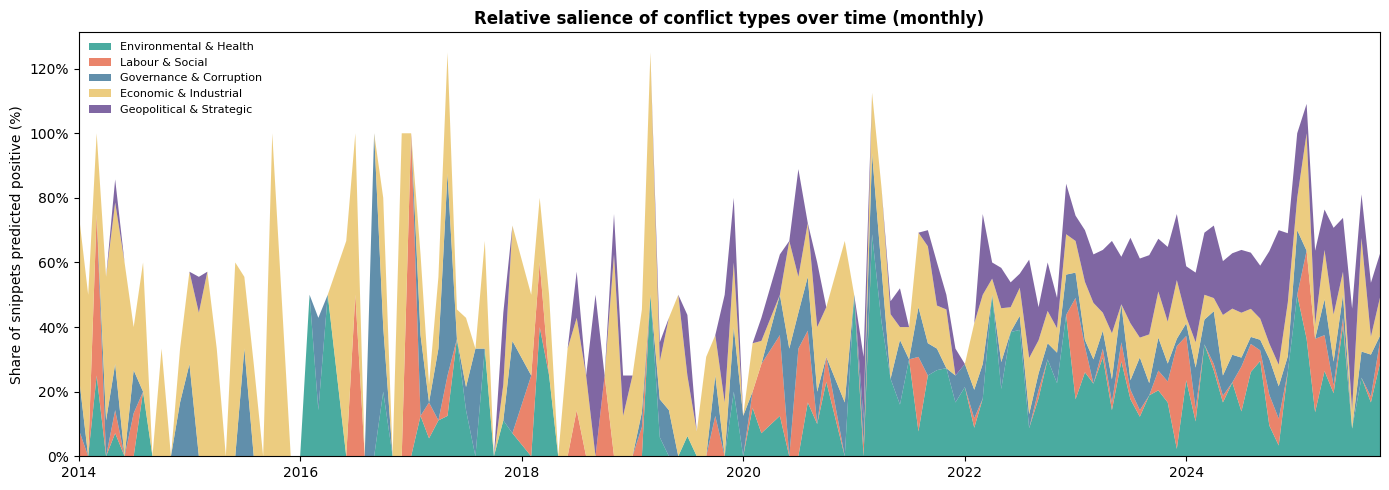

Snippets with >= 1 positive label : 1,533
Multi-label snippets              : 111

Label distribution:
  Environmental & Health: 494
  Labour & Social: 147
  Governance & Corruption: 208
  Economic & Industrial: 388
  Geopolitical & Strategic: 409

Saved: snippets_nli_positives.xlsx


In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

CONFLICT_COLS = ['env_health', 'labour_social', 'governance_corruption',
                 'economic_industrial', 'geopolitical_strategic']
LABELS = {
    'env_health'            : 'Environmental & Health',
    'labour_social'         : 'Labour & Social',
    'governance_corruption' : 'Governance & Corruption',
    'economic_industrial'   : 'Economic & Industrial',
    'geopolitical_strategic': 'Geopolitical & Strategic',
}
COLORS = ['#2a9d8f','#e76f51','#457b9d','#e9c46a','#6a4c93']

# salience plot 
plot_df = snippets_nli.copy()
plot_df['month'] = pd.to_datetime(plot_df['date']).dt.to_period('M')
monthly = plot_df.groupby('month')[[f'pred__{c}' for c in CONFLICT_COLS]].sum()
totals  = plot_df.groupby('month').size()
rel     = monthly.div(totals, axis=0) * 100
rel.columns = [LABELS[c] for c in CONFLICT_COLS]
rel.index   = rel.index.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.stackplot(rel.index, [rel[LABELS[c]] for c in CONFLICT_COLS],
             labels=[LABELS[c] for c in CONFLICT_COLS],
             colors=COLORS, alpha=0.85)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylabel('Share of snippets predicted positive (%)')
ax.set_title('Relative salience of conflict types over time (monthly)',
             fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=8, frameon=False)
ax.set_xlim(rel.index.min(), rel.index.max())
plt.tight_layout()
OUT_PLOT = r'conflict_salience_nli.png'
plt.savefig(OUT_PLOT, dpi=150, bbox_inches='tight')
plt.show()

#  export positively-labeled snippets to Excel
positives = snippets_nli[snippets_nli['n_conflicts_predicted'] >= 1].copy()

# add human-readable conflict label column
positives['conflict_labels'] = positives.apply(
    lambda r: '; '.join([LABELS[c] for c in CONFLICT_COLS if r[f'pred__{c}'] == 1]), axis=1
)

print(f'Snippets with >= 1 positive label : {len(positives):,}')
print(f'Multi-label snippets              : {(positives["n_conflicts_predicted"] > 1).sum():,}')
print('\nLabel distribution:')
for c in CONFLICT_COLS:
    print(f'  {LABELS[c]}: {positives[f"pred__{c}"].sum():,}')

OUT_XL = r'snippets_nli_positives.xlsx'
positives.to_excel(OUT_XL, index=False)
print(f'\nSaved: {OUT_XL}')


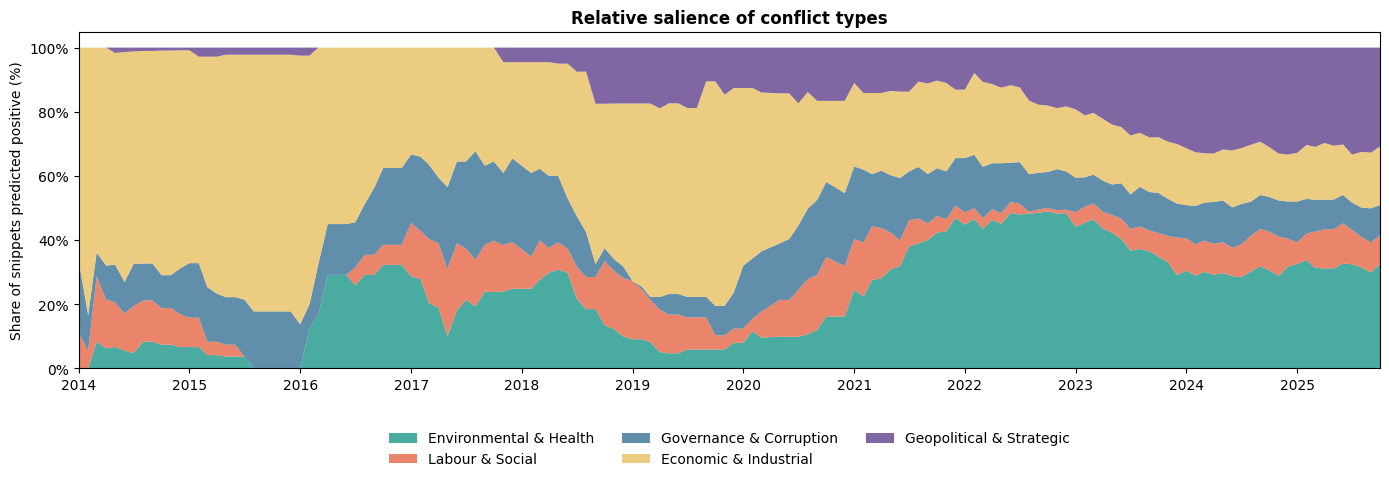

Saved: conflict_salience_nli.png


In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates

CONFLICT_COLS = ['env_health', 'labour_social', 'governance_corruption',
                 'economic_industrial', 'geopolitical_strategic']
LABELS = {
    'env_health'            : 'Environmental & Health',
    'labour_social'         : 'Labour & Social',
    'governance_corruption' : 'Governance & Corruption',
    'economic_industrial'   : 'Economic & Industrial',
    'geopolitical_strategic': 'Geopolitical & Strategic',
}
COLORS = ['#2a9d8f','#e76f51','#457b9d','#e9c46a','#6a4c93']

plot_df = snippets_nli.copy()
plot_df['period'] = pd.to_datetime(plot_df['date']).dt.to_period('M')

pred_cols = [f'pred__{c}' for c in CONFLICT_COLS]
monthly   = plot_df.groupby('period')[pred_cols].sum()
totals    = plot_df.groupby('period').size()
rel       = monthly.div(totals, axis=0) * 100
rel       = rel.div(rel.sum(axis=1), axis=0) * 100   # ← normalise rows to 100%
rel       = rel.rolling(12, min_periods=1).mean()
rel.columns = [LABELS[c] for c in CONFLICT_COLS]
rel.index   = rel.index.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.stackplot(rel.index, [rel[LABELS[c]] for c in CONFLICT_COLS],
             labels=[LABELS[c] for c in CONFLICT_COLS],
             colors=COLORS, alpha=0.85)

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylabel('Share of snippets predicted positive (%)')
ax.set_title('Relative salience of conflict types',
             fontsize=12, fontweight='bold')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,               # adjust to fit your number of categories
    frameon=False,
)
ax.set_xlim(rel.index.min(), rel.index.max())
plt.tight_layout()

OUT = r'conflict_salience_nli.png'
plt.savefig(OUT, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT}')


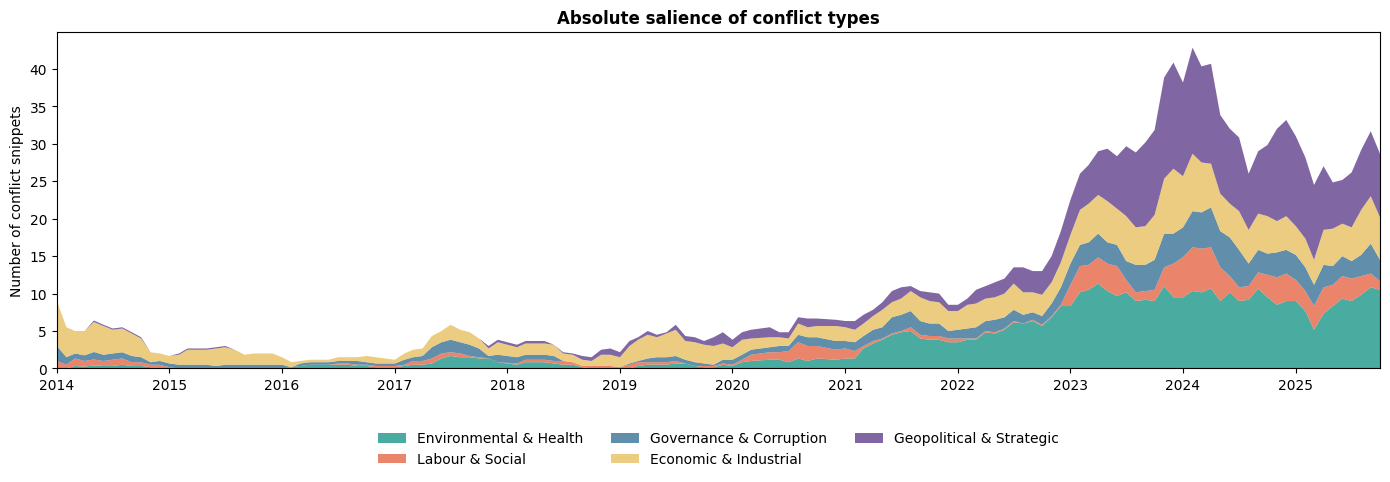

Saved: conflict_snippets_over_time.png


In [13]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

CONFLICT_COLS = ['env_health', 'labour_social', 'governance_corruption',
                 'economic_industrial', 'geopolitical_strategic']
LABELS = {
    'env_health'            : 'Environmental & Health',
    'labour_social'         : 'Labour & Social',
    'governance_corruption' : 'Governance & Corruption',
    'economic_industrial'   : 'Economic & Industrial',
    'geopolitical_strategic': 'Geopolitical & Strategic',
}
COLORS = ['#2a9d8f', '#e76f51', '#457b9d', '#e9c46a', '#6a4c93']
THRESHOLD = 0.6

# snippet-level monthly counts
plot_df = snippets_nli.copy()
plot_df['month'] = pd.to_datetime(plot_df['date']).dt.to_period('M')

pred_cols = [f'pred__{c}' for c in CONFLICT_COLS]
monthly_counts = plot_df.groupby('month')[pred_cols].sum()
monthly_counts.columns = [LABELS[c] for c in CONFLICT_COLS]

# 6-month rolling average
counts_smooth = monthly_counts.rolling(6, min_periods=1).mean()
counts_smooth.index = counts_smooth.index.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.stackplot(
    counts_smooth.index,
    [counts_smooth[LABELS[c]] for c in CONFLICT_COLS],
    labels=[LABELS[c] for c in CONFLICT_COLS],
    colors=COLORS, alpha=0.85,
)
ax.set_ylabel('Number of conflict snippets')
ax.set_title(
    f'Absolute salience of conflict types',
    fontsize=12, fontweight='bold',
)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False)
ax.set_xlim(counts_smooth.index.min(), counts_smooth.index.max())
plt.tight_layout()

OUT = r'conflict_snippets_over_time.png'
plt.savefig(OUT, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT}')


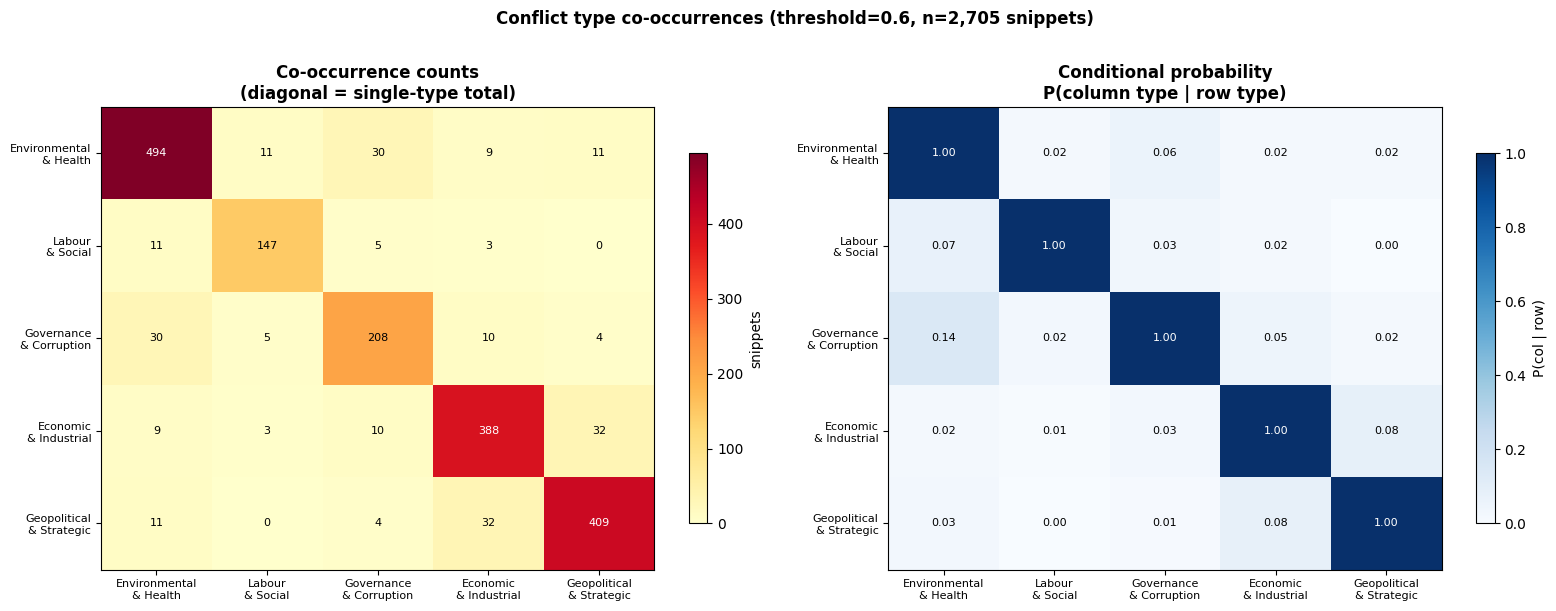

Saved: conflict_cooccurrence.png

Top co-occurring pairs (off-diagonal):
  economic_industrial + geopolitical_strategic: 32  (8% of economic_industrial, 8% of geopolitical_strategic)
  env_health + governance_corruption: 30  (6% of env_health, 14% of governance_corruption)
  env_health + labour_social: 11  (2% of env_health, 7% of labour_social)
  env_health + geopolitical_strategic: 11  (2% of env_health, 3% of geopolitical_strategic)
  governance_corruption + economic_industrial: 10  (5% of governance_corruption, 3% of economic_industrial)
  env_health + economic_industrial: 9  (2% of env_health, 2% of economic_industrial)
  labour_social + governance_corruption: 5  (3% of labour_social, 2% of governance_corruption)
  governance_corruption + geopolitical_strategic: 4  (2% of governance_corruption, 1% of geopolitical_strategic)
  labour_social + economic_industrial: 3  (2% of labour_social, 1% of economic_industrial)
  labour_social + geopolitical_strategic: 0  (0% of labour_social, 0

In [14]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

CONFLICT_COLS = ['env_health', 'labour_social', 'governance_corruption',
                 'economic_industrial', 'geopolitical_strategic']
LABELS = {
    'env_health'            : 'Environmental\n& Health',
    'labour_social'         : 'Labour\n& Social',
    'governance_corruption' : 'Governance\n& Corruption',
    'economic_industrial'   : 'Economic\n& Industrial',
    'geopolitical_strategic': 'Geopolitical\n& Strategic',
}

pred_df = snippets_nli[[f'pred__{c}' for c in CONFLICT_COLS]].copy()
pred_df.columns = CONFLICT_COLS

# absolute co-occurrence: how many snippets have both type i and type j
n = len(CONFLICT_COLS)
cooc = np.zeros((n, n), dtype=int)
for i, ci in enumerate(CONFLICT_COLS):
    for j, cj in enumerate(CONFLICT_COLS):
        cooc[i, j] = (pred_df[ci] & pred_df[cj]).sum()

# conditional: P(col j | row i) = cooc[i,j] / cooc[i,i]  (diagonal = 1.0)
diag = np.diag(cooc).astype(float)
diag[diag == 0] = np.nan
cond = cooc / diag[:, None]

short = [LABELS[c] for c in CONFLICT_COLS]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── left: absolute counts ──────────────────────────────────────────────────
im0 = axes[0].imshow(cooc, cmap='YlOrRd', aspect='auto')
plt.colorbar(im0, ax=axes[0], shrink=0.8, label='snippets')
axes[0].set_xticks(range(n)); axes[0].set_xticklabels(short, fontsize=8)
axes[0].set_yticks(range(n)); axes[0].set_yticklabels(short, fontsize=8)
axes[0].set_title('Co-occurrence counts\n(diagonal = single-type total)', fontweight='bold')
for i in range(n):
    for j in range(n):
        axes[0].text(j, i, f'{cooc[i,j]:,}', ha='center', va='center',
                     fontsize=8, color='black' if cooc[i,j] < cooc.max()*0.7 else 'white')

# ── right: conditional probability (row → col) ────────────────────────────
im1 = axes[1].imshow(cond, cmap='Blues', vmin=0, vmax=1, aspect='auto')
plt.colorbar(im1, ax=axes[1], shrink=0.8, label='P(col | row)')
axes[1].set_xticks(range(n)); axes[1].set_xticklabels(short, fontsize=8)
axes[1].set_yticks(range(n)); axes[1].set_yticklabels(short, fontsize=8)
axes[1].set_title('Conditional probability\nP(column type | row type)', fontweight='bold')
for i in range(n):
    for j in range(n):
        v = cond[i, j]
        axes[1].text(j, i, f'{v:.2f}' if not np.isnan(v) else '—',
                     ha='center', va='center', fontsize=8,
                     color='black' if v < 0.6 else 'white')

plt.suptitle(f'Conflict type co-occurrences (threshold=0.6, n={pred_df.shape[0]:,} snippets)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
OUT = r'conflict_cooccurrence.png'
plt.savefig(OUT, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT}')

# summary: most common pairs
print('\nTop co-occurring pairs (off-diagonal):')
pairs = [(cooc[i,j], CONFLICT_COLS[i], CONFLICT_COLS[j])
         for i in range(n) for j in range(i+1, n)]
for count, a, b in sorted(pairs, reverse=True):
    pct_a = 100 * count / cooc[CONFLICT_COLS.index(a), CONFLICT_COLS.index(a)]
    pct_b = 100 * count / cooc[CONFLICT_COLS.index(b), CONFLICT_COLS.index(b)]
    print(f'  {a} + {b}: {count:,}  '
          f'({pct_a:.0f}% of {a}, {pct_b:.0f}% of {b})')


In [15]:
# Manual spot-check validation
# Draws a stratified random sample of predicted positives + borderline negatives
# per conflict type and exports to Excel for in-line human review.
#
# Sampling strategy (per conflict type):
#   - 30 predicted positives  → check precision (are these correct?)
#   - 15 borderline negatives (prob 0.40–0.59) → check recall boundary
#   - 10 confident negatives  (prob < 0.30)    → confirm true negatives
# Reviewer fills: manual_label (1/0) and notes column.

import pandas as pd
import numpy as np
from openpyxl import load_workbook
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter

CONFLICT_COLS = ['env_health', 'labour_social', 'governance_corruption',
                 'economic_industrial', 'geopolitical_strategic']
LABELS = {
    'env_health'            : 'Environmental & Health',
    'labour_social'         : 'Labour & Social',
    'governance_corruption' : 'Governance & Corruption',
    'economic_industrial'   : 'Economic & Industrial',
    'geopolitical_strategic': 'Geopolitical & Strategic',
}
THRESHOLD = 0.6
N_POS      = 30   # positives per class
N_BORDER   = 15   # borderline negatives per class (0.40–0.59)
N_NEG      = 10   # confident negatives per class (< 0.30)
SEED       = 42

rng = np.random.default_rng(SEED)
frames = []

for col in CONFLICT_COLS:
    prob_col = f'prob__{col}'
    pred_col = f'pred__{col}'
    label    = LABELS[col]

    positives  = snippets_nli[snippets_nli[pred_col] == 1]
    borderline = snippets_nli[(snippets_nli[prob_col] >= 0.40) &
                               (snippets_nli[prob_col] <  THRESHOLD)]
    negatives  = snippets_nli[snippets_nli[prob_col] <  0.30]

    s_pos    = positives.sample(min(N_POS,    len(positives)),  random_state=SEED)
    s_border = borderline.sample(min(N_BORDER, len(borderline)), random_state=SEED)
    s_neg    = negatives.sample(min(N_NEG,    len(negatives)),  random_state=SEED)

    for df_part, stratum in [(s_pos,    'positive'),
                              (s_border, 'borderline'),
                              (s_neg,    'negative')]:
        if len(df_part) == 0:
            continue
        chunk = pd.DataFrame({
            'conflict_type'    : label,
            'stratum'          : stratum,
            'article_id'       : df_part['article_id'].values,
            'date'             : pd.to_datetime(df_part['date']).dt.strftime('%Y-%m').values,
            'outlet'           : df_part['outlet'].values if 'outlet' in df_part.columns else '',
            'snippet'          : df_part['snippet_clean'].values,
            'model_prob'       : df_part[prob_col].values.round(3),
            'model_pred'       : df_part[pred_col].values,
            'manual_label'     : '',   # reviewer fills: 1 = conflict present, 0 = not
            'notes'            : '',   # reviewer fills: optional comment
        })
        frames.append(chunk)

val_df = pd.concat(frames, ignore_index=True)
val_df = val_df.sample(frac=1, random_state=SEED).reset_index(drop=True)  # shuffle rows

OUT_XL = r'/p/tmp/charlott/Dropbox/Paper_Indonesia_Nickel/ln_training/manual_validation.xlsx'

# ── write to Excel with formatting ───────────────────────────────────────
with pd.ExcelWriter(OUT_XL, engine='openpyxl') as writer:
    # sheet 1: instructions
    instr = pd.DataFrame({'Instructions': [
        'Fill the manual_label column: 1 = conflict present, 0 = not present.',
        'Use the notes column for any comments.',
        'stratum = positive  → model predicted this as the conflict type (check precision)',
        'stratum = borderline → model was uncertain (prob 0.40–0.59); check if it should be positive',
        'stratum = negative   → model was confident this is NOT the type (spot-check false negatives)',
        f'Decision threshold: {THRESHOLD}',
        f'Total rows to review: {len(val_df)}',
    ]})
    instr.to_excel(writer, sheet_name='Instructions', index=False)

    # sheet 2: validation sample
    val_df.to_excel(writer, sheet_name='Validation', index=False)

# ── apply visual formatting ───────────────────────────────────────────────
wb  = load_workbook(OUT_XL)
ws  = wb['Validation']

fill_pos    = PatternFill('solid', fgColor='D6EAD6')   # green  – positive
fill_border = PatternFill('solid', fgColor='FFF3CD')   # yellow – borderline
fill_neg    = PatternFill('solid', fgColor='F8D7DA')   # red    – negative
bold        = Font(bold=True)

# header row
for cell in ws[1]:
    cell.font      = Font(bold=True)
    cell.alignment = Alignment(wrap_text=True, vertical='top')

# colour rows by stratum; set snippet column width
snippet_col_idx = val_df.columns.get_loc('snippet') + 1
ws.column_dimensions[get_column_letter(snippet_col_idx)].width = 80

for row in ws.iter_rows(min_row=2, max_row=ws.max_row):
    stratum = row[val_df.columns.get_loc('stratum')].value
    fill    = fill_pos if stratum == 'positive' else (
              fill_border if stratum == 'borderline' else fill_neg)
    for cell in row:
        cell.fill      = fill
        cell.alignment = Alignment(wrap_text=True, vertical='top')

wb.save(OUT_XL)
print(f'Saved: {OUT_XL}')

# ── summary ───────────────────────────────────────────────────────────────
summary = val_df.groupby(['conflict_type', 'stratum']).size().unstack(fill_value=0)
print(f'\nRows per class × stratum (total={len(val_df)}):'  )
print(summary.to_string())

Saved: /p/tmp/charlott/Dropbox/Paper_Indonesia_Nickel/ln_training/manual_validation.xlsx

Rows per class × stratum (total=226):
stratum                   borderline  negative  positive
conflict_type                                           
Economic & Industrial             10        10        30
Environmental & Health             7        10        30
Geopolitical & Strategic           5        10        30
Governance & Corruption            3        10        30
Labour & Social                    1        10        30


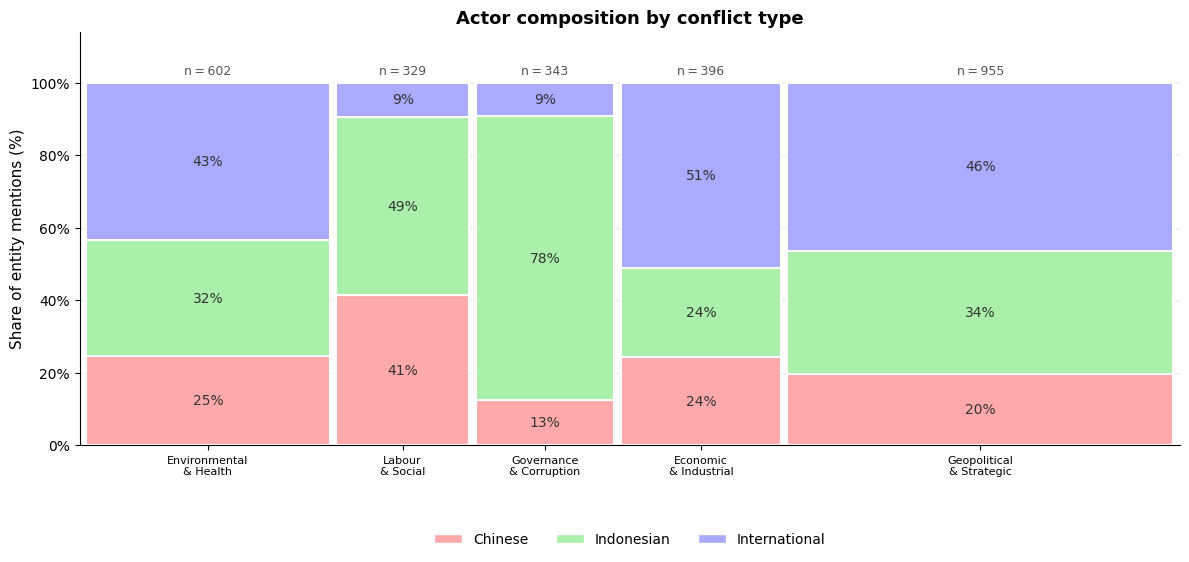

Saved: actor_composition_by_conflict.png


In [16]:
# ── Self-contained: load conflict predictions from CSV if not already in memory ──
import pandas as pd
if 'snippets_nli' not in dir():
    snippets_nli = pd.read_csv('snippets_nli_predictions.csv')
    print(f'Loaded {len(snippets_nli):,} rows from snippets_nli_predictions.csv')

import json, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ── Actor group definitions (same codebook as NB3B) ──────────────────────────
with open('ner_actor_codebook.json', 'r', encoding='utf-8') as fh:
    codebook = json.load(fh)

BROAD_GROUPS = {
    'Chinese': {
        'Chinese DFIs (banks)', 'Chinese firms/SOEs',
        'Chinese government',   'Chinese worker',
    },
    'Indonesian': {
        'Indonesian government: central government/president',
        'Indonesian government: local government (provincial/regional officials)',
        'Indonesian firms and local elites',
        'Indonesian local civil society',
        'Indonesian local community & workers',
    },
    'International': {
        'International governmental and intergovernmental actors',
        'International companies',
        'International NGOs/watchdog',
    },
}

GROUP_COLORS = {'Chinese': '#FFAAAA', 'Indonesian': '#AAF0AA', 'International': '#AAAAFF'}

def _expand_terms(terms):
    out, seen = [], set()
    for raw in terms:
        for seg in str(raw).split(';'):
            seg = seg.strip()
            if not seg:
                continue
            for alt in seg.split(' OR '):
                alt = alt.strip()
                if alt and alt.lower() not in seen:
                    seen.add(alt.lower())
                    out.append(alt)
    return out

def build_group_pattern(labels):
    terms = []
    for rec in codebook:
        if rec['actor_label'] in labels:
            terms.extend(_expand_terms(rec['named_entities']) +
                         _expand_terms(rec['trigger_phrases']))
    if not terms:
        return None
    return re.compile(
        '|'.join(r'\b' + re.escape(t) + r'\b' for t in terms),
        re.IGNORECASE
    )

group_patterns = {g: build_group_pattern(labels) for g, labels in BROAD_GROUPS.items()}

# ── Count entity mentions per group per conflict type ─────────────────────────
CONFLICT_COLS = ['env_health', 'labour_social', 'governance_corruption',
                 'economic_industrial', 'geopolitical_strategic']
LABELS_2LINE  = {
    'env_health':             'Environmental\n& Health',
    'labour_social':          'Labour\n& Social',
    'governance_corruption':  'Governance\n& Corruption',
    'economic_industrial':    'Economic\n& Industrial',
    'geopolitical_strategic': 'Geopolitical\n& Strategic',
}

rows = []
for col in CONFLICT_COLS:
    sub = snippets_nli[snippets_nli[f'pred__{col}'] == 1].copy()
    grp_counts = {}
    for grp, pat in group_patterns.items():
        if pat is None:
            grp_counts[grp] = 0
        else:
            grp_counts[grp] = int(sub['snippet'].apply(
                lambda t: len(pat.findall(str(t)))
            ).sum())
    n_total = sum(grp_counts.values())
    for grp, cnt in grp_counts.items():
        rows.append({
            'conflict' : col,
            'group'    : grp,
            'count'    : cnt,
            'n_total'  : n_total,
            'share'    : cnt / n_total if n_total > 0 else 0,
        })

actor_conflict_df = pd.DataFrame(rows)

# preserve the original CONFLICT_COLS order
conflict_order = CONFLICT_COLS

# ── Proportional bar widths (width ∝ n) ──────────────────────────────────────
n_map    = actor_conflict_df.groupby('conflict')['n_total'].first()
n_vals   = np.array([n_map[c] for c in conflict_order], dtype=float)
n_fracs  = n_vals / n_vals.sum()

# bars span a total x-range of 5 units; gap ≈ 1 mm between bars
total_x    = 5.0
gap        = 0.03
bar_widths = n_fracs * (total_x - gap * (len(conflict_order) - 1))

centers = []
left = 0.0
for w in bar_widths:
    centers.append(left + w / 2)
    left += w + gap
centers = np.array(centers)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5.5))
fig.patch.set_facecolor('white')

bottom = np.zeros(len(conflict_order))
group_order = ['Chinese', 'Indonesian', 'International']

for grp in group_order:
    vals = np.array([
        actor_conflict_df[
            (actor_conflict_df['conflict'] == c) &
            (actor_conflict_df['group']    == grp)
        ]['share'].values[0] * 100
        for c in conflict_order
    ])
    ax.bar(centers, vals, bottom=bottom, width=bar_widths,
           label=grp, color=GROUP_COLORS[grp],
           edgecolor='white', linewidth=1.5)
    for i, (b, v) in enumerate(zip(bottom, vals)):
        if v >= 5:
            ax.text(centers[i], b + v / 2, f'{v:.0f}%',
                    ha='center', va='center', fontsize=10,
                    color='#333333')
    bottom += vals

# n labels above bars
for i, col in enumerate(conflict_order):
    ax.text(centers[i], 101.5, f'n = {n_map[col]:,}',
            ha='center', va='bottom', fontsize=9, color='#555555')

ax.set_xticks(centers)
ax.set_xticklabels([LABELS_2LINE[c] for c in conflict_order], fontsize=8)
ax.set_xlim(-gap, total_x + gap)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, 114)
ax.set_ylabel('Share of entity mentions (%)', fontsize=11)
ax.set_title('Actor composition by conflict type', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.set_axisbelow(True)
ax.grid(axis='y', linestyle='--', alpha=0.3)

handles = [plt.Rectangle((0, 0), 1, 1, color=GROUP_COLORS[g], ec='white')
           for g in group_order]
ax.legend(handles, group_order, ncol=3,
          loc='upper center', bbox_to_anchor=(0.5, -0.18),
          frameon=False, fontsize=10)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
OUT = 'actor_composition_by_conflict.png'
plt.savefig(OUT, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {OUT}')

Overall (baseline) share across all snippets:
  Chinese         23.9%  (946 mentions)
  Indonesian      39.3%  (1,554 mentions)
  International   36.8%  (1,455 mentions)


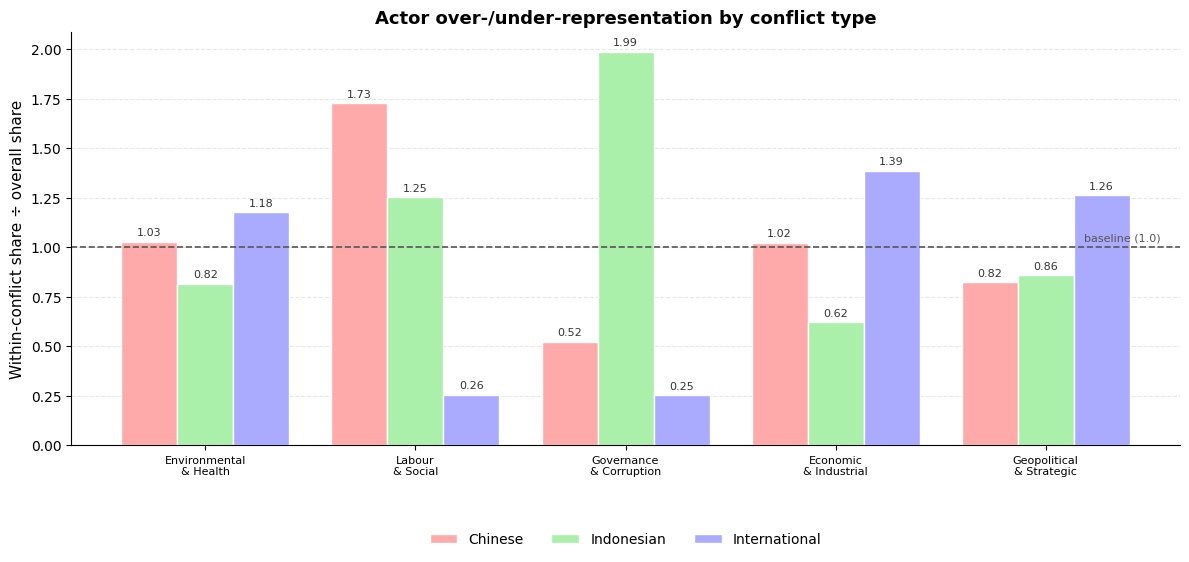

Saved: actor_representation_index_by_conflict.png


In [17]:
# ── Actor over-/under-representation by conflict type ─────────────────────────
# For each actor group, compare its share of entity mentions WITHIN a conflict
# type against its OVERALL share across all snippets. The ratio is a
# specialization index: > 1 means the group is over-represented in that conflict
# type relative to its baseline; < 1 means under-represented.

# baseline: each group's share of entity mentions across ALL snippets
baseline_counts = {
    grp: (int(snippets_nli['snippet'].apply(lambda t: len(pat.findall(str(t)))).sum())
          if pat is not None else 0)
    for grp, pat in group_patterns.items()
}
baseline_total = sum(baseline_counts.values())
baseline_share = {g: (c / baseline_total if baseline_total > 0 else 0)
                  for g, c in baseline_counts.items()}

print('Overall (baseline) share across all snippets:')
for g in group_order:
    print(f'  {g:<14} {100 * baseline_share[g]:5.1f}%  ({baseline_counts[g]:,} mentions)')

# specialization index = within-conflict share / overall share
def _within_share(conflict, grp):
    return actor_conflict_df[
        (actor_conflict_df['conflict'] == conflict) &
        (actor_conflict_df['group']    == grp)
    ]['share'].values[0]

ratio = {
    grp: np.array([
        (_within_share(c, grp) / baseline_share[grp]) if baseline_share[grp] > 0 else np.nan
        for c in conflict_order
    ])
    for grp in group_order
}

# ── Grouped bar chart ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5.5))
fig.patch.set_facecolor('white')

x      = np.arange(len(conflict_order))
n_grp  = len(group_order)
width  = 0.8 / n_grp

for j, grp in enumerate(group_order):
    offset = (j - (n_grp - 1) / 2) * width
    bars = ax.bar(x + offset, ratio[grp], width=width,
                  label=grp, color=GROUP_COLORS[grp],
                  edgecolor='white', linewidth=1.0)
    for b, v in zip(bars, ratio[grp]):
        if np.isfinite(v):
            ax.text(b.get_x() + b.get_width() / 2, v + 0.02, f'{v:.2f}',
                    ha='center', va='bottom', fontsize=8, color='#333333')

ax.axhline(1.0, color='#555555', linestyle='--', linewidth=1.2)
ax.text(len(conflict_order) - 0.45, 1.02, 'baseline (1.0)',
        ha='right', va='bottom', fontsize=8, color='#555555')

ax.set_xticks(x)
ax.set_xticklabels([LABELS_2LINE[c] for c in conflict_order], fontsize=8)
ax.set_ylabel('Within-conflict share ÷ overall share', fontsize=11)
ax.set_title('Actor over-/under-representation by conflict type', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.set_axisbelow(True)
ax.grid(axis='y', linestyle='--', alpha=0.3)

handles = [plt.Rectangle((0, 0), 1, 1, color=GROUP_COLORS[g], ec='white')
           for g in group_order]
ax.legend(handles, group_order, ncol=3,
          loc='upper center', bbox_to_anchor=(0.5, -0.18),
          frameon=False, fontsize=10)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
OUT = 'actor_representation_index_by_conflict.png'
plt.savefig(OUT, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {OUT}')


In [18]:
# ── LaTeX tables: actor composition by conflict type ─────────────────────────
# Table 1: broad groups (Chinese / Indonesian / International)
# Table 2: individual actor labels within each BROAD_GROUP
# Both rely on actor_conflict_df, n_map, group_patterns from the figure cell.

LABELS_LATEX = {
    'env_health':             r'Environmental \& Health',
    'labour_social':          r'Labour \& Social',
    'governance_corruption':  r'Governance \& Corruption',
    'economic_industrial':    r'Economic \& Industrial',
    'geopolitical_strategic': r'Geopolitical \& Strategic',
}

# ── Table 1: broad groups ─────────────────────────────────────────────────────
lines1 = [
    r'\begin{table}[ht]',
    r'\centering',
    (r'\caption{Share of actor entity mentions by umbrella category in snippets '
     r'predicted positive for each conflict type (\%).}'),
    r'\label{tab:actor_composition_by_conflict}',
    r'\begin{tabular}{lrrr}',
    r'\toprule',
    r'Conflict type & Chinese & Indonesian & International \\',
    r'\midrule',
]
for col in CONFLICT_COLS:
    row     = actor_conflict_df[actor_conflict_df['conflict'] == col].set_index('group')['share']
    chinese = row.get('Chinese',       0) * 100
    indo    = row.get('Indonesian',    0) * 100
    intl    = row.get('International', 0) * 100
    lines1.append(f'{LABELS_LATEX[col]} & {chinese:.1f} & {indo:.1f} & {intl:.1f} \\\\')
lines1 += [r'\bottomrule', r'\end{tabular}', r'\end{table}']

tex1 = '\n'.join(lines1) + '\n'
with open('table_actor_composition_by_conflict.tex', 'w', encoding='utf-8') as fh:
    fh.write(tex1)
print('── Table 1: broad groups ──────────────────────────────────────────────')
print(tex1)

# ── Table 2: individual actors within each broad group ────────────────────────
# Build per-actor patterns and count hits per conflict type.
ACTOR_ORDER = [
    ('Chinese',       ['Chinese DFIs (banks)', 'Chinese firms/SOEs',
                       'Chinese government',   'Chinese worker']),
    ('Indonesian',    ['Indonesian government: central government/president',
                       'Indonesian government: local government (provincial/regional officials)',
                       'Indonesian firms and local elites',
                       'Indonesian local civil society',
                       'Indonesian local community & workers']),
    ('International', ['International governmental and intergovernmental actors',
                       'International companies',
                       'International NGOs/watchdog']),
]

ACTOR_LABELS_LATEX = {
    'Chinese DFIs (banks)':                                                    r'Chinese DFIs (banks)',
    'Chinese firms/SOEs':                                                      r'Chinese firms/SOEs',
    'Chinese government':                                                      r'Chinese government',
    'Chinese worker':                                                          r'Chinese workers',
    'Indonesian government: central government/president':                     r'Indonesian central government',
    'Indonesian government: local government (provincial/regional officials)': r'Indonesian local government',
    'Indonesian firms and local elites':                                       r'Indonesian firms \& elites',
    'Indonesian local civil society':                                          r'Indonesian civil society',
    'Indonesian local community & workers':                                    r'Indonesian community \& workers',
    'International governmental and intergovernmental actors':                 r'Intl.\ governmental actors',
    'International companies':                                                 r'International companies',
    'International NGOs/watchdog':                                             r'International NGOs',
}

# build individual actor patterns
import re as _re
def _build_single_pattern(actor_label):
    terms, seen = [], set()
    for rec in codebook:
        if rec['actor_label'] == actor_label:
            for raw_list in (rec['named_entities'], rec['trigger_phrases']):
                for raw in raw_list:
                    for seg in str(raw).split(';'):
                        seg = seg.strip()
                        if not seg:
                            continue
                        for alt in seg.split(' OR '):
                            alt = alt.strip()
                            if alt and alt.lower() not in seen:
                                seen.add(alt.lower())
                                terms.append(alt)
    if not terms:
        return None
    return _re.compile('|'.join(r'\b' + _re.escape(t) + r'\b' for t in terms), _re.IGNORECASE)

actor_patterns_individual = {
    actor: _build_single_pattern(actor)
    for _, actors in ACTOR_ORDER
    for actor in actors
}

# count hits per actor per conflict type
actor_counts = {}   # {actor_label: {conflict_col: count}}
for actor, pat in actor_patterns_individual.items():
    actor_counts[actor] = {}
    for col in CONFLICT_COLS:
        sub = snippets_nli[snippets_nli[f'pred__{col}'] == 1]
        if pat is None:
            actor_counts[actor][col] = 0
        else:
            actor_counts[actor][col] = int(
                sub['snippet'].apply(lambda t: len(pat.findall(str(t)))).sum()
            )

# build table 2 (actors as rows, conflict types as columns)
short_conflict = {
    'env_health':             'Env.',
    'labour_social':          'Labour',
    'governance_corruption':  'Gov.',
    'economic_industrial':    'Econ.',
    'geopolitical_strategic': 'Geo.',
}

col_header = ' & '.join(short_conflict[c] for c in CONFLICT_COLS)
lines2 = [
    r'\begin{table}[ht]',
    r'\centering',
    (r'\caption{Share of entity mentions per individual actor label within '
     r'conflict-type-positive snippets (\% of total entity hits for that conflict type).}'),
    r'\label{tab:actor_individual_by_conflict}',
    r'\begin{tabular}{lrrrrr}',
    r'\toprule',
    f'Actor & {col_header} \\\\',
    r'\midrule',
]

for broad_grp, actors in ACTOR_ORDER:
    lines2.append(r'\multicolumn{6}{l}{\textit{' + broad_grp + r'}} \\')
    for actor in actors:
        shares = []
        for col in CONFLICT_COLS:
            share = actor_counts[actor][col] / n_map[col] * 100 if n_map[col] > 0 else 0
            shares.append(f'{share:.1f}')
        row_label = ACTOR_LABELS_LATEX[actor]
        lines2.append(f'\\quad {row_label} & ' + ' & '.join(shares) + r' \\')
    lines2.append(r'\midrule')

# replace last \midrule with \bottomrule
lines2[-1] = r'\bottomrule'
lines2 += [r'\end{tabular}', r'\end{table}']

tex2 = '\n'.join(lines2) + '\n'
with open('table_actor_individual_by_conflict.tex', 'w', encoding='utf-8') as fh:
    fh.write(tex2)
print('\n── Table 2: individual actors ─────────────────────────────────────────')
print(tex2)
print('Saved: table_actor_composition_by_conflict.tex + table_actor_individual_by_conflict.tex')


── Table 1: broad groups ──────────────────────────────────────────────
\begin{table}[ht]
\centering
\caption{Share of actor entity mentions by umbrella category in snippets predicted positive for each conflict type (\%).}
\label{tab:actor_composition_by_conflict}
\begin{tabular}{lrrr}
\toprule
Conflict type & Chinese & Indonesian & International \\
\midrule
Environmental \& Health & 24.6 & 32.1 & 43.4 \\
Labour \& Social & 41.3 & 49.2 & 9.4 \\
Governance \& Corruption & 12.5 & 78.1 & 9.3 \\
Economic \& Industrial & 24.5 & 24.5 & 51.0 \\
Geopolitical \& Strategic & 19.7 & 33.8 & 46.5 \\
\bottomrule
\end{tabular}
\end{table}


── Table 2: individual actors ─────────────────────────────────────────
\begin{table}[ht]
\centering
\caption{Share of entity mentions per individual actor label within conflict-type-positive snippets (\% of total entity hits for that conflict type).}
\label{tab:actor_individual_by_conflict}
\begin{tabular}{lrrrrr}
\toprule
Actor & Env. & Labour & Gov. & Econ. & G